<a href="https://colab.research.google.com/github/Nandhini-ds/movie-recommendation-system/blob/main/Zee_Recommender_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

Build a personalized movie recommendation system using user-based collaborative filtering, where recommendations are generated based on historical ratings and similarity between users by leveraging user demographic information (such as age, gender, and zip code) along with movie features, with the objective of improving user experience, increasing user engagement, and maximizing content consumption.

**Importing Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#ratings
ratings = pd.read_csv(
    "zee-ratings.dat",
    sep="::",
    engine = "python")

In [ ]:
#users
users = pd.read_csv("zee-users.dat",
                    sep = "::",
                    engine = "python")

In [ ]:
#movies file
movies = pd.read_csv(
    "zee-movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1"
)

In [ ]:
ratings

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


 **Basic Exploration of Data**

In [ ]:
ratings.shape

(1000209, 4)

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [ ]:
print("unique users:",ratings['UserID'].nunique())
print("unique movies:", movies['Movie ID'].nunique())

unique users: 6040
unique movies: 3883


In [ ]:
users

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   Zip-code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [ ]:
movies

,Movie ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie ID  3883 non-null   int64 
 1   Title     3883 non-null   object
 2   Genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [ ]:
ratings.describe()

,UserID,MovieID,Rating,Timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


Ratings are on a scale of 1 to 5. About 75% of ratings are 4 or lower, with an average rating of ~3.6.

In [ ]:
ratings.nunique()

,0
UserID,6040
MovieID,3706
Rating,5
Timestamp,458455


In [ ]:
movies.nunique()

,0
MovieID,3883
Title,3883
Genres,301


**Data type conversion**

In [ ]:
users['Gender'] = users['Gender'].astype('category')
users['Age'] = users['Age'].astype('category')       # or map to age ranges
users['Occupation'] = users['Occupation'].astype('category')
users['Zip-code'] = users['Zip-code'].astype('category')


In [ ]:
ratings.isnull().sum()

,0
UserID,0
MovieID,0
Rating,0
Timestamp,0


In [ ]:
users.isnull().sum()

,0
UserID,0
Gender,0
Age,0
Occupation,0
Zip-code,0


In [ ]:
movies.isnull().sum()

,0
Movie ID,0
Title,0
Genres,0


In [ ]:
len(ratings) / (len(users) * len(movies))

0.04264679797998748

In [ ]:
movies.describe(include='O').T

,count,unique,top,freq
Title,3883,3883,"Contender, The (2000)",1
Genres,3883,301,Drama,843


In [ ]:
users.describe(include='category').T

,count,unique,top,freq
Gender,6040,2,M,4331
Age,6040,7,25,2096
Occupation,6040,21,4,759
Zip-code,6040,3439,48104,19


*  The dataset has more **male** users.
*  Users with **25-year-olds** being the largest age group.
*  **Occupation code 4** is the most common, and users are widely distributed across zip-codes.
*  Among all **zip-codes, 48104** has the highest frequency, with 19 users.

In [ ]:
ratings['Rating'].value_counts(normalize=True)*100

,proportion
Rating,
4,34.889808
3,26.114242
5,22.626271
2,10.753453
1,5.616226


In [ ]:
movies['Genres'].value_counts(normalize=True)*100

,proportion
Genres,
Drama,21.710018
Comedy,13.417461
Horror,4.584084
Comedy|Drama,4.172032
Comedy|Romance,3.656966
...,...
Drama|Film-Noir,0.025753
Comedy|Horror|Sci-Fi,0.025753
Adventure|Drama|Romance|Sci-Fi,0.025753


In [ ]:
users['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
M,71.705298
F,28.294702


In [ ]:
users['Age'].value_counts(normalize=True)*100

,proportion
Age,
25,34.701987
35,19.751656
18,18.261589
45,9.105960
50,8.211921
56,6.291391
1,3.675497


In [ ]:
age_dict = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+"
}

In [ ]:
occupation_dict = {
    0: "other or not specified",
    1: "academic/educator",
    2: "artist",
    3: "clerical/admin",
    4: "college/grad student",
    5: "customer service",
    6: "doctor/health care",
    7: "executive/managerial",
    8: "farmer",
    9: "homemaker",
    10: "K-12 student",
    11: "lawyer",
    12: "programmer",
    13: "retired",
    14: "sales/marketing",
    15: "scientist",
    16: "self-employed",
    17: "technician/engineer",
    18: "tradesman/craftsman",
    19: "unemployed",
    20: "writer"
}

In [ ]:
users['Occupation Cat'] = users['Occupation'].map(occupation_dict)
users['Age_Group'] = users['Age'].map(age_dict)

**Exploring Data with Visualizations**

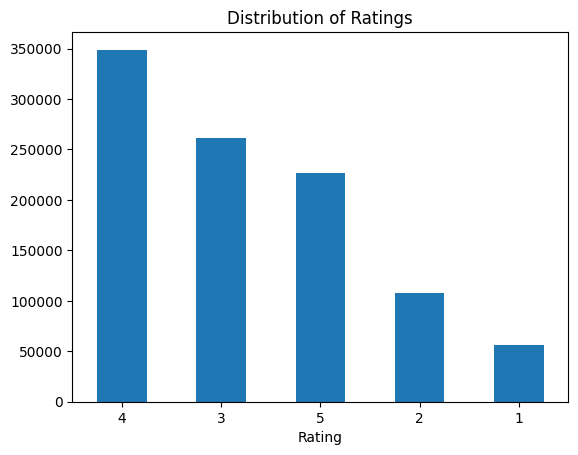

In [ ]:
ratings['Rating'].value_counts().plot(kind='bar')
plt.xticks(rotation=1)
plt.title("Distribution of Ratings")
plt.show()

**Insights**

*  The majority of **ratings are 4**, accounting for roughly **35%** of all ratings.

*  Ratings of 3 and 5 are also common, while **1 and 2** appear relatively **rarely.**

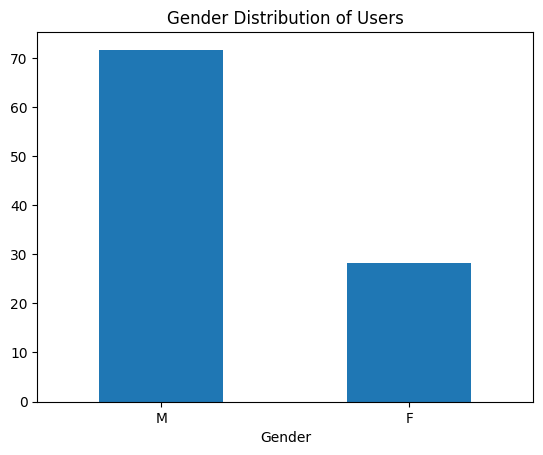

In [ ]:
round(users['Gender'].value_counts(normalize=True)*100,2
  ).plot(kind='bar')
plt.xticks(rotation = 1)
plt.title('Gender Distribution of Users')
plt.show()

About 72% of users are male, while 28% are female, showing that the platform is mostly used by males.

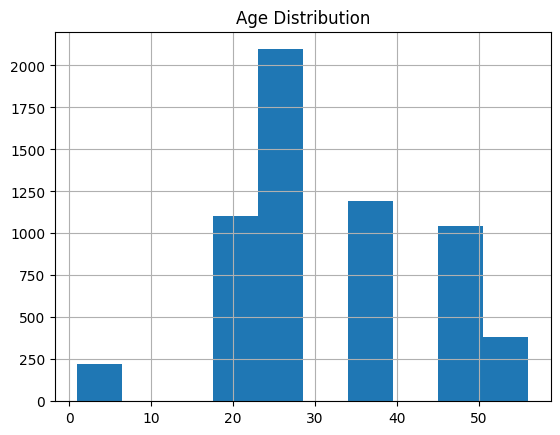

In [ ]:
users.Age.hist()
plt.title('Age Distribution')
plt.show()

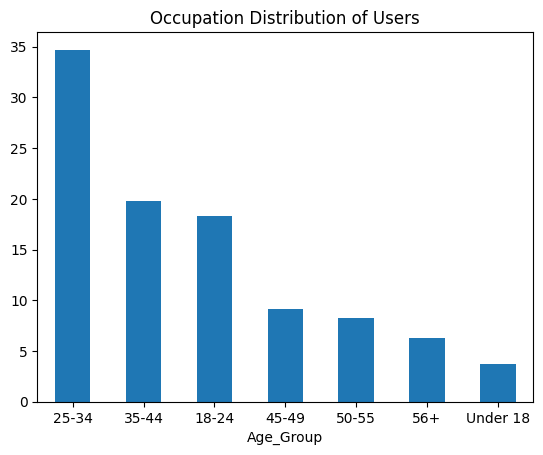

In [ ]:
round(users['Age_Group'].value_counts(normalize=True)*100, 2)\
    .plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Occupation Distribution of Users')
plt.show()

**Insights**

*  Users aged **25-34** are the most common in this dataset, making up about 34.7% of all users, indicating that the platform is popular among younger and middle-aged users.

*  Users aged **44** and above have the lowest subscription count.

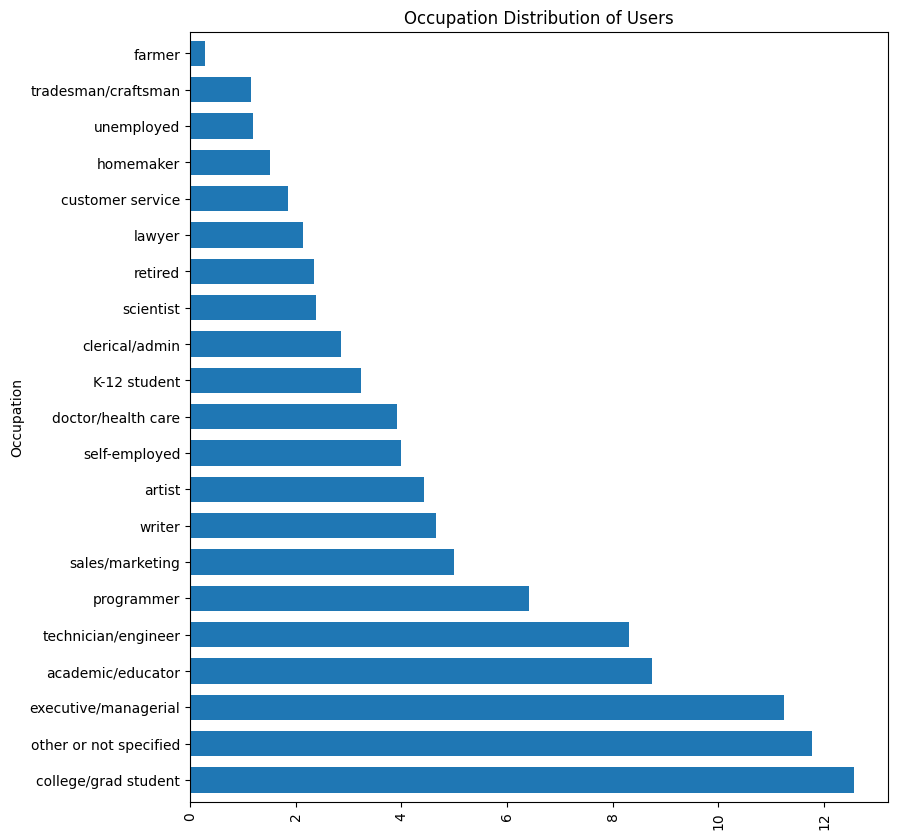

In [ ]:
plt.figure(figsize=(9,10))
round(users['Occupation'].value_counts(normalize=True)*100, 2)\
    .plot(kind='barh', width=0.7)
plt.xticks(rotation=90)
plt.title('Occupation Distribution of Users')
plt.show()

**Insights**

*  **College/grad students** are the **largest** user segment on the Zee platform, accounting for **12.6%** of users, followed by the **Not Specified** category **(11.8%)** and the **Executive/Managerial segment (11.2%)**.

*  This suggests that younger users and those with higher income levels are more likely to subscribe to the Zee platform.

In [ ]:
demo = (users['Zip-code'].value_counts(normalize=True)*100).head(5).reset_index()

In [ ]:
state = {
    "48104": "Michigan",
    "22903": "Virginia",
    "55104": "Minnesota",
    "94110": "California",
    "10025": "New York"
}

In [ ]:
demo

,Zip-code,proportion
0,48104,0.314570
1,22903,0.298013
2,55104,0.281457
3,94110,0.281457
4,10025,0.264901


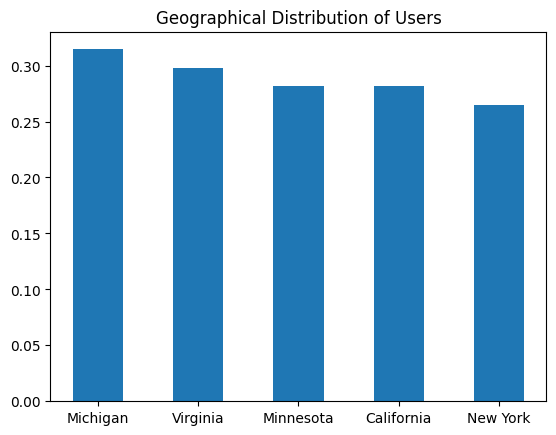

In [ ]:
demo['State'] = demo['Zip-code'].astype(str).map(state)
plt.bar(demo['State'], demo['proportion'], width=0.5)
plt.title("Geographical Distribution of Users")
plt.show()

Top user concentration is observed in US states such as Michigan, Virginia, Minnesota, California, and New York.

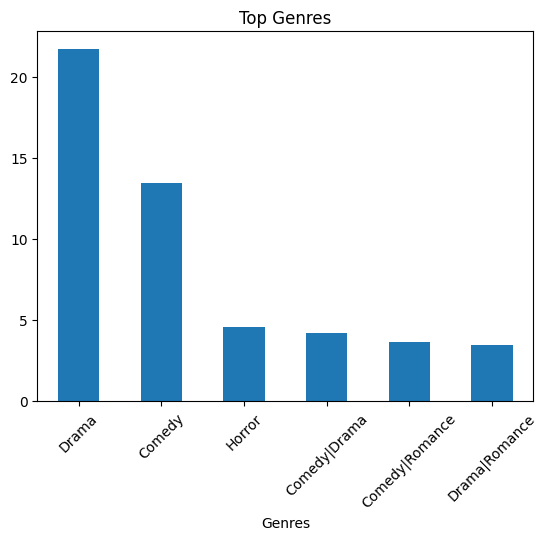

In [ ]:
round(
    movies['Genres'].value_counts(normalize=True)*100,2).head(6).plot(kind='bar'
    )
plt.title("Top Genres")
plt.xticks(rotation = 45)
plt.show()

**Insights**

*  **Drama** is the most common genre, representing about **21.7%** of all movies in the dataset. It plays a key role among movie genres, followed by **Comedy (13.4%) and Horror (4.6%).**

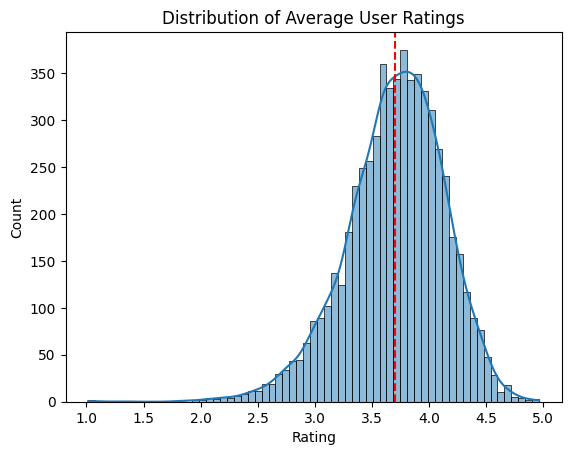

In [ ]:
avg_user_rating = ratings.groupby('UserID')['Rating'].mean()

sns.histplot(avg_user_rating, kde=True)
plt.axvline(avg_user_rating.mean(), color='red', linestyle='--')
plt.title("Distribution of Average User Ratings")
plt.show()

**Insights**

*  The distribution of average user ratings shows a left tail, indicating that most users give average to high ratings, while a small group of users usually give low ratings.

*  This imbalance may introduce user bias in the recommendation system.

In [ ]:
releaseyear = movies['Title'].str.extract(r'\((\d{4})\)')
decade=(releaseyear.astype(int)//10) *10
de = pd.DataFrame(decade.value_counts().sort_index())
de

,count
0,
1910,3
1920,34
1930,77
1940,126
1950,168
1960,191
1970,247
1980,598
1990,2283


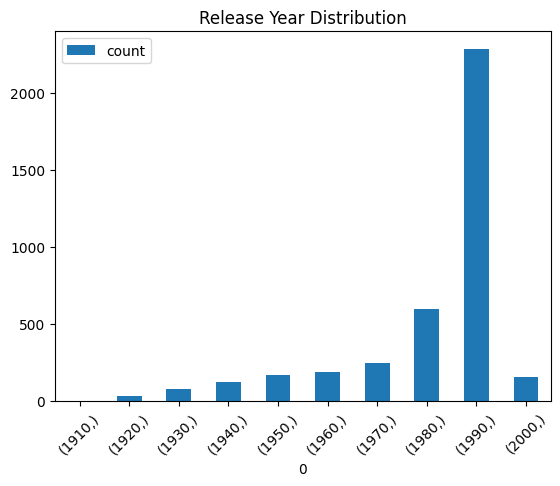

In [ ]:
de.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Release Year Distribution')
plt.show()

*  A significant number of movies were released in the **90's decade** (1990s), while other decades show much lower counts.


**Movie with maximum number of ratings**

In [ ]:
movies.rename(columns ={'Movie ID': 'MovieID'}, inplace=True)

In [ ]:
movie_freq = (
    ratings.groupby("MovieID")
    .size()
    .reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)

In [ ]:
movie_freq[['rating_count','Title']].head()

,rating_count,Title
0,3428,American Beauty (1999)
1,2991,Star Wars: Episode IV - A New Hope (1977)
2,2990,Star Wars: Episode V - The Empire Strikes Back...
3,2883,Star Wars: Episode VI - Return of the Jedi (1983)
4,2672,Jurassic Park (1993)


In [ ]:
movie_freq = movie_freq.merge(movies, on="MovieID")
movie_freq.head(5)

,MovieID,rating_count,Title,Genres
0,2858,3428,American Beauty (1999),Comedy|Drama
1,260,2991,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
2,1196,2990,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
3,1210,2883,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
4,480,2672,Jurassic Park (1993),Action|Adventure|Sci-Fi


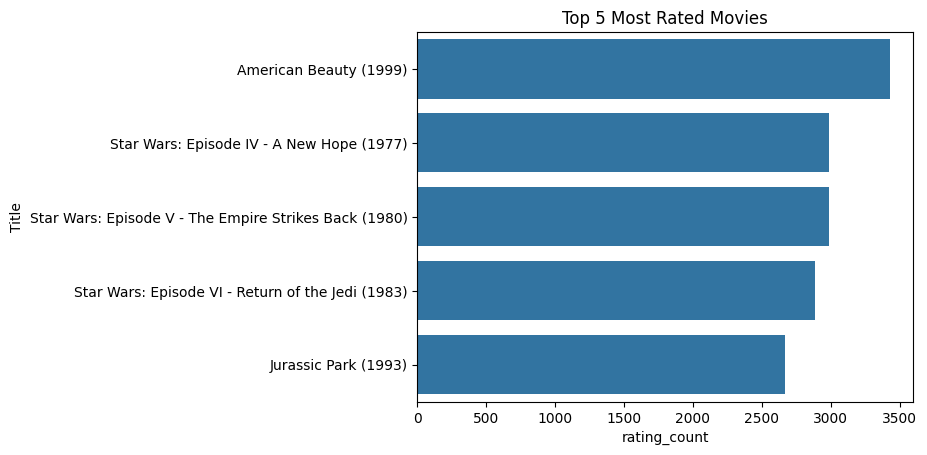

In [ ]:
sns.barplot(x='rating_count', y='Title', data=movie_freq.head())
plt.title("Top 5 Most Rated Movies")
plt.show()

In [ ]:
movie_freq[movie_freq['rating_count']<5]['Title']

,Title
3416,Penitentiary II (1982)
3417,Phat Beach (1996)
3418,Babyfever (1994)
3419,Carmen Miranda: Bananas Is My Business (1994)
3420,"First Love, Last Rites (1997)"
...,...
3701,Open Season (1996)
3702,Telling You (1998)
3703,"Uninvited Guest, An (2000)"
3704,Beauty (1998)


In [ ]:
movie_freq[movie_freq['rating_count']<=5]['Title'].nunique()

329

**Distribution of Ratings per User and per Movie**

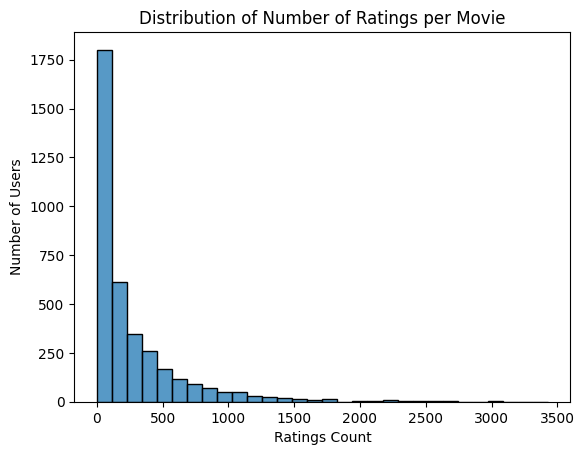

In [ ]:
movie_freq1= ratings.groupby("MovieID").size()

sns.histplot(movie_freq1, bins=30)
plt.title("Distribution of Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.ylabel("Number of Users")
plt.show()

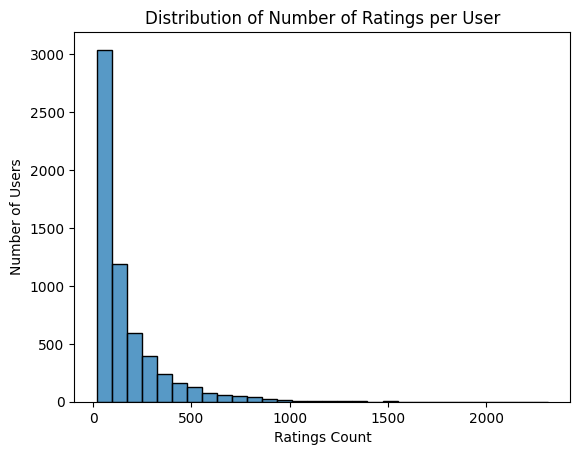

In [ ]:
user_freq = ratings.groupby("UserID").size()

sns.histplot(user_freq, bins=30)
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Ratings Count")
plt.ylabel("Number of Users")
plt.show()

**Insights**

*  **American Beauty (1999)** has received the highest number of ratings **(3,428)** in the dataset. The **Star Wars series (Episodes IV, V, and VI)** also received nearly as many ratings, making them among the most rated movies. Overall, these titles are the most popular in terms of user engagement.

*  Only a few users are highly active on the platform, giving many ratings. Most users rate only a small number of movies. This is expected, as it is unlikely that every user watches or interacts with all movies on any platform.

*  The dataset contains 329 low-interaction movies (≤5 ratings), which limits the effectiveness of collaborative filtering models, as these items lack sufficient data to compute reliable similarities.

**Merging Dataframe**

In [ ]:
merged_df = ratings.merge(movies, on='MovieID', how='left')
merged_df = merged_df.merge(users, on='UserID', how='left')
merged_df.columns

Index(['UserID', 'MovieID', 'Rating', 'Timestamp', 'Title', 'Genres', 'Gender',
       'Age', 'Occupation', 'Zip-code'],
      dtype='object')

In [ ]:
merged_df['Genres'] = merged_df['Genres'].str.split('|')
merged_df.head()

,UserID,MovieID,Rating,Timestamp,Title,Genres,Gender,Age,Occupation,Zip-code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),[Drama],F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),"[Animation, Children's, Musical]",F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),"[Musical, Romance]",F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),[Drama],F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)","[Animation, Children's, Comedy]",F,1,10,48067


In [ ]:
merged_df = merged_df.explode('Genres')
merged_df.head()

,UserID,MovieID,Rating,Timestamp,Title,Genres,Gender,Age,Occupation,Zip-code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Children's,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical,F,1,10,48067


**Demographic Preferences Across Genres**

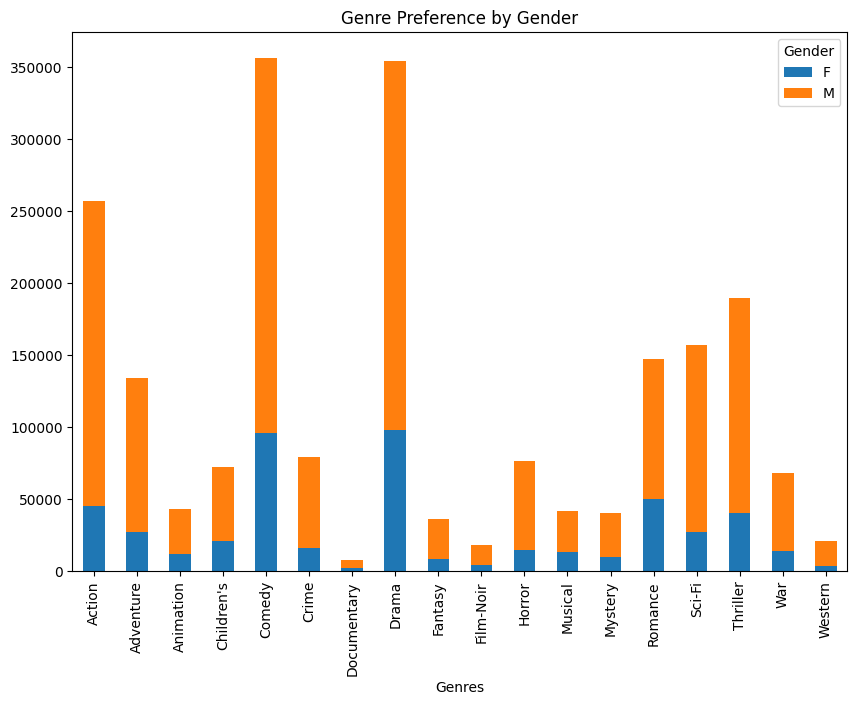

In [ ]:
genre_gender = pd.crosstab(merged_df["Genres"], merged_df["Gender"])

genre_gender.plot(kind="bar", stacked=True, figsize =(10,7))
plt.title("Genre Preference by Gender")
plt.show()

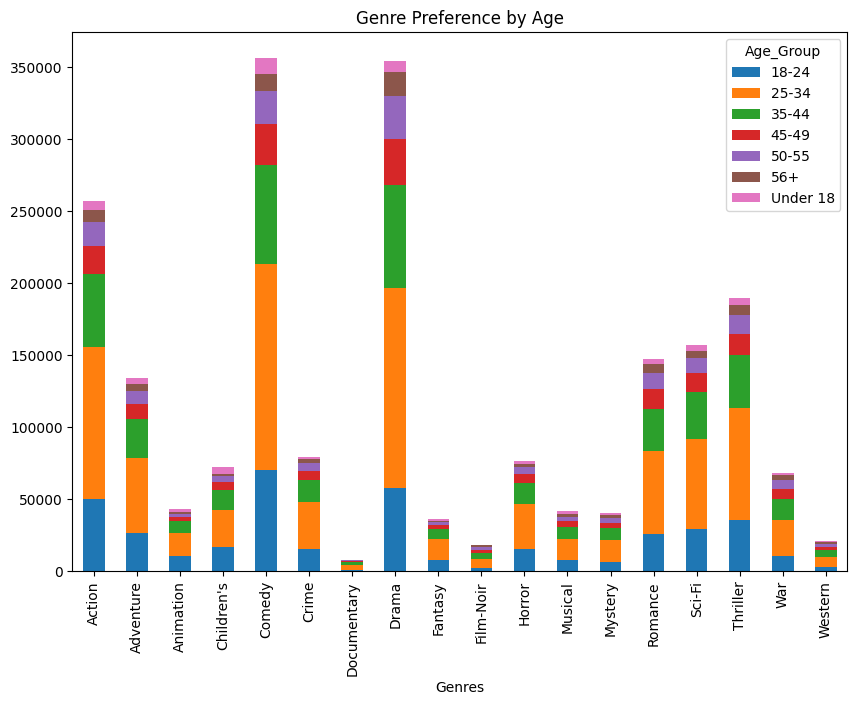

In [ ]:
genre_age = pd.crosstab(merged_df["Genres"], merged_df["Age_Group"])

genre_age.plot(kind="bar", stacked=True, figsize=(10,7))
plt.title("Genre Preference by Age")
plt.show()

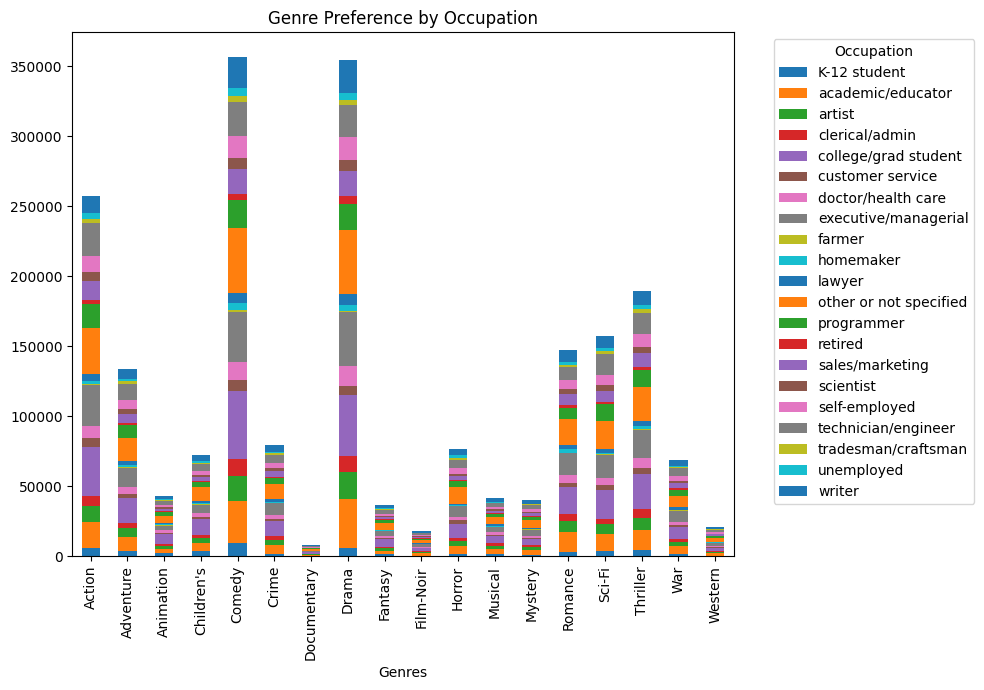

In [ ]:
genre_occupation = pd.crosstab(merged_df["Genres"], merged_df["Occupation Cat"])

genre_occupation.plot(kind="bar", stacked=True, figsize=(10,7))
plt.title("Genre Preference by Occupation")
plt.legend(title="Occupation",
           bbox_to_anchor=(1.05, 1),
           loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
code = demo['Zip-code'].tolist()
code

['48104', '22903', '55104', '94110', '10025']

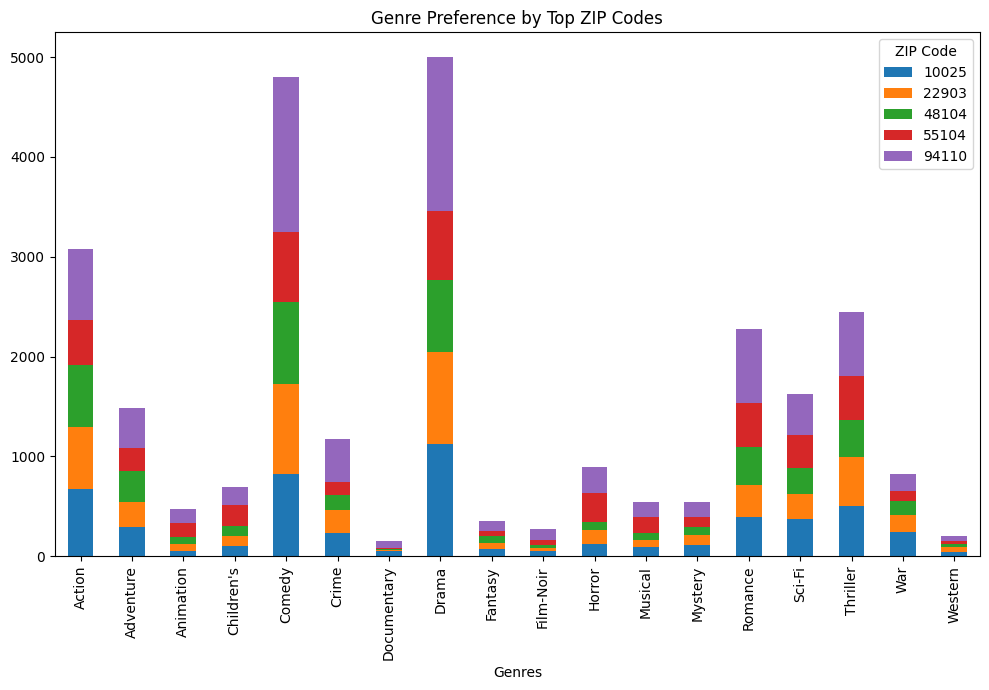

In [ ]:
zipcode = merged_df[merged_df['Zip-code'].isin(code)]
pd.crosstab(
    zipcode['Genres'],zipcode['Zip-code']).plot(kind='bar', stacked =True, figsize=(10,7)
    )
plt.title("Genre Preference by Top ZIP Codes")
plt.legend(title="ZIP Code")
plt.tight_layout()
plt.show()

**Insights**

*  **Drama and Comedy** are the **topmost** preferred genres across all demographics (age, gender, occupation, and state).

*  **Action** consistently follows as the next most popular genre.

*  **Documentary and Film Noir** are the **least preferred genres** among all users.

#Feature Enginnering

In [ ]:
ratings['Timestamp'] = pd.to_datetime(ratings['Timestamp'], unit='s')
ratings['Year'] = ratings['Timestamp'].dt.year
ratings['Month'] = ratings['Timestamp'].dt.month
ratings['DayofWeek'] = ratings['Timestamp'].dt.dayofweek
ratings['Hour'] =ratings['Timestamp'].dt.hour

In [ ]:
#user agg
user_agg_features = ratings.groupby('UserID').agg(
    user_mean_rating = ('Rating', 'mean'),
    user_median_rating = ('Rating', 'median'),
    user_rating_std = ('Rating', 'std'),
    user_rating_count = ('Rating', 'count'),
    user_min_rating=('Rating', 'min'),
    user_max_rating=('Rating', 'max')
).reset_index()

In [ ]:
user_agg_features

,UserID,user_mean_rating,user_median_rating,user_rating_std,user_rating_count,user_min_rating,user_max_rating
0,1,4.188679,4.0,0.680967,53,3,5
1,2,3.713178,4.0,1.001513,129,1,5
2,3,3.901961,4.0,0.984985,51,1,5
3,4,4.190476,4.0,1.077917,21,1,5
4,5,3.146465,3.0,1.132699,198,1,5
...,...,...,...,...,...,...,...
6035,6036,3.302928,3.0,1.023684,888,1,5
6036,6037,3.717822,4.0,0.877910,202,1,5
6037,6038,3.800000,4.0,1.105013,20,1,5
6038,6039,3.878049,4.0,0.730881,123,2,5


In [ ]:
#user time based features
user_time_based_feats = ratings.groupby('UserID').agg(
    User_activity_interval = ('Timestamp',lambda x: x.sort_values().diff().dt.total_seconds().mean()),
    ratings_per_month_user=('Month', lambda x: len(x) / ratings['Month'].nunique())
).reset_index()


In [ ]:
movie_agg_feats = ratings.groupby('MovieID').agg(
    movie_mean_rating=('Rating', 'mean'),
    movie_median_rating=('Rating', 'median'),
    movie_rating_std=('Rating', 'std'),
    movie_rating_count=('Rating', 'count'),
    movie_min_rating=('Rating', 'min'),
    movie_max_rating=('Rating', 'max')
).reset_index()

In [ ]:
movie_time_based_feats = ratings.groupby('MovieID').agg(
    movie_rating_span_days=('Timestamp', lambda x: (x.max() - x.min()).days + 1),
    avg_time_gap_movie=('Timestamp', lambda x: x.sort_values().diff().dt.total_seconds().mean()),
    rating_frequency_movie=('MovieID', 'count')
).reset_index()

In [ ]:
movie_time_based_feats

,MovieID,movie_rating_span_days,avg_time_gap_movie,rating_frequency_movie
0,1,1031,4.286986e+04,2077
1,2,1022,1.260925e+05,701
2,3,1036,1.875792e+05,478
3,4,922,4.710033e+05,170
4,5,1036,3.033055e+05,296
...,...,...,...,...
3701,3948,873,8.759948e+04,862
3702,3949,825,2.351998e+05,304
3703,3950,787,1.282301e+06,54
3704,3951,784,1.734729e+06,40


# Collaborative Filtering with Pearson Correlation

In [ ]:
pivot_ratings = ratings.pivot(index = 'UserID', columns = 'MovieID').Rating
UserID = pivot_ratings.index
MovieID = pivot_ratings.columns
pivot_ratings

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
UserID,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
movie_corr = pivot_ratings.corr(method='pearson')

In [ ]:
id_name = dict(zip(movies['MovieID'], movies['Title']))
name_id = dict(zip(movies['Title'], movies['MovieID']))

In [ ]:
from difflib import get_close_matches
def recommend_movies(movie_name, n=5):
   movie_id = name_id.get(movie_name)
   if movie_id is None:
      suggestions = get_close_matches(movie_name, name_id.keys(), n=3, cutoff=0.6)
      if len(suggestions) == 0:
            return []
      else:
            return [(s, None) for s in suggestions]

   similar = movie_corr[movie_id].sort_values(ascending = False).dropna()
   similar = similar.iloc[1:n+1]

   results = []

   for movie_id, score in similar.items():
       results.append((id_name[movie_id], round(score, 3)))
   return results

In [ ]:
recommend_movies('Waiting to Exhale (1995)',5)

,4
MovieID,
2972,1.0
389,1.0
2388,1.0
1336,1.0
3850,1.0


In [ ]:
movie_name = 'Waiting to Exhale (1995)'
result = recommend_movies(movie_name, 5)

if len(result) == 0:
    print("No recommendations found.")
else:
    print(f"Movies similar to '{movie_name}':")
    for i, (movie, score) in enumerate(result, start=1):
        if score is None:
            print(f"{i}. {movie} (suggestion)")
        else:
            print(f"{i}. {movie} → {score}")

Movies similar to 'Waiting to Exhale (1995)':
1. Red Sorghum (Hong Gao Liang) (1987) → 1.0
2. Colonel Chabert, Le (1994) → 1.0
3. Steam: The Turkish Bath (Hamam) (1997) → 1.0
4. Body Parts (1991) → 1.0
5. Whatever Happened to Aunt Alice? (1969) → 1.0


Due to the high sparsity of the user–item matrix, Pearson correlation often results in unreliable similarity scores when computed over very few common users. To mitigate this issue, we restrict the analysis to movies with sufficient interaction history and users with a minimum number of ratings, ensuring statistically meaningful correlations.

**Item-Based Similarity (Pearson Correlation)**

In [ ]:
users_count = ratings['UserID'].value_counts().reset_index()
users_count.columns = ['UserID', 'count']
active_users = users_count[users_count['count'] > 200]

In [ ]:
movie_counts = ratings['MovieID'].value_counts().reset_index()
movie_counts.columns = ['MovieID', 'count']
popular_movies = movie_counts[movie_counts['count'] > 100]

In [ ]:
corr_rec = ratings[
    ratings['UserID'].isin(active_users['UserID']) &
    ratings['MovieID'].isin(popular_movies['MovieID'])]

In [ ]:
pearson_cor = corr_rec.pivot(index = 'UserID', columns = 'MovieID').Rating
pearson_cor

MovieID,1,2,3,4,5,6,7,9,10,11,...,3927,3928,3929,3930,3932,3936,3937,3948,3949,3952
UserID,,,,,,,,,,,,,,,,,,,,,
10,5.0,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
18,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,2.0,NaN,3.0,NaN,NaN,NaN,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,5.0,NaN,3.0,3.0,NaN,NaN,4.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6035,4.0,NaN,1.0,2.0,1.0,NaN,3.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
corr_df=pearson_cor.corr(method = 'pearson')
corr_df

MovieID,1,2,3,4,5,6,7,9,10,11,...,3927,3928,3929,3930,3932,3936,3937,3948,3949,3952
MovieID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.216929,0.183430,0.311434,0.174866,0.042804,0.184104,-0.090416,0.167628,0.181457,...,0.314564,0.033294,0.245737,0.121235,0.154175,-0.109950,0.056120,0.109747,0.197446,0.183583
2,0.216929,1.000000,0.231674,0.093298,0.366643,0.081932,0.231171,0.386512,0.243118,0.354632,...,0.266150,0.276358,0.035731,0.136852,0.269002,-0.061719,0.430622,0.253195,0.069078,0.081982
3,0.183430,0.231674,1.000000,0.208508,0.418730,0.169048,0.222267,0.151163,0.298955,0.216327,...,0.003661,0.311035,0.381904,0.377858,0.140948,-0.098510,0.329445,0.336738,0.032478,0.220456
4,0.311434,0.093298,0.208508,1.000000,0.374215,-0.003679,0.108184,-0.681895,0.010868,0.089381,...,0.365367,0.225749,-0.870388,0.620674,0.421831,0.578947,-0.310087,0.163545,-0.434783,0.170038
5,0.174866,0.366643,0.418730,0.374215,1.000000,0.068877,0.296401,0.538139,0.222594,0.335023,...,0.343219,0.217574,0.138845,0.573313,0.404197,0.151990,0.280828,0.403812,-0.142407,-0.028967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,-0.109950,-0.061719,-0.098510,0.578947,0.151990,-0.295745,0.282858,-0.500000,-0.101326,0.049029,...,-0.041651,0.186902,0.684922,0.092083,0.265000,1.000000,0.073127,0.254467,0.020963,-0.035223
3937,0.056120,0.430622,0.329445,-0.310087,0.280828,0.177930,0.198452,-0.102129,0.017651,0.085463,...,0.344110,0.429942,0.516398,0.249144,0.284790,0.073127,1.000000,0.179994,0.392232,0.187084
3948,0.109747,0.253195,0.336738,0.163545,0.403812,0.065551,0.022073,0.083513,0.223987,0.044495,...,0.269845,-0.232962,0.124392,0.079842,0.023131,0.254467,0.179994,1.000000,-0.037428,0.127439


In [ ]:
import re
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize titles for lookup
def normalize_title(title):
    return re.sub(r'\(\d{4}\)', '', title).strip().lower()

# Build lookup dictionaries
name_id = {normalize_title(title): movie_id for title, movie_id in zip(movies['Title'], movies['MovieID'])}
id_name = {movie_id: title for title, movie_id in zip(movies['Title'], movies['MovieID'])}

# Recommendation + visualization function
def recommend_corr(movie_input, n=5, cutoff=0.5, show_heatmap=True):
    movie_input_norm = normalize_title(movie_input)
    movie_id = name_id.get(movie_input_norm)
    if movie_id is None:
        suggestions = get_close_matches(movie_input_norm, name_id.keys(), n=1, cutoff=cutoff)
        if not suggestions:
            print(f"Sorry, '{movie_input}' is not in the database.")
            return
        movie_id = name_id[suggestions[0]]

    print(f"\nShowing recommendations for: '{id_name[movie_id]}'\n")

    # Get top-N correlations
    similar = corr_df[movie_id].dropna().sort_values(ascending=False)[1:n+1]
    results = [(id_name[mid], round(score,3)) for mid, score in similar.items()]

    return results

In [ ]:
movie_input = input("Enter a movie name: ")
recommendations = recommend_corr(movie_input, n=5)

if isinstance(recommendations, str):
    print(recommendations)
else:
    print("Top 5 similar movies:")
    for i, (title, score) in enumerate(recommendations, 1):
        print(f"{i}. {title} (score: {score})")

Enter a movie name: requiem for a dream

Showing recommendations for: 'Requiem for a Dream (2000)'

Top 5 similar movies:
1. Pork Chop Hill (1959) (score: 0.87)
2. Bank Dick, The (1940) (score: 0.816)
3. Abbott and Costello Meet Frankenstein (1948) (score: 0.75)
4. Frankenstein (1931) (score: 0.714)
5. Bronco Billy (1980) (score: 0.712)


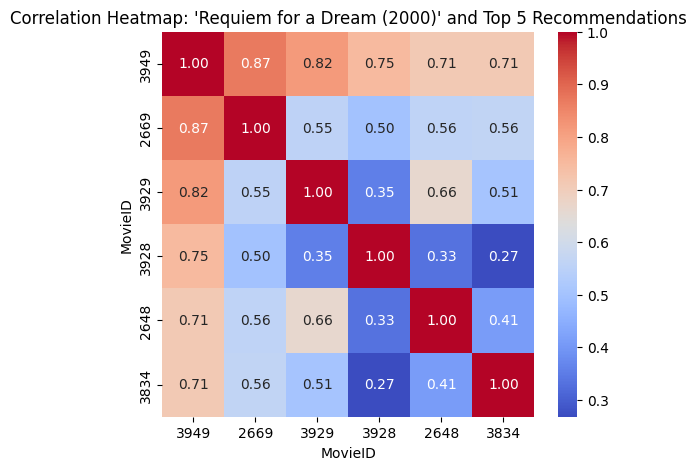

In [ ]:
movie_input = "Requiem for a Dream (2000)"
top_n = 5

# Get the normalized movie ID
movie_id = name_id[normalize_title(movie_input)]

# Get top-N similar movies from corr_df
similar = corr_df[movie_id].dropna().sort_values(ascending=False)[1:top_n+1]
top_movie_ids = list(similar.index)

# Plot heatmap only
subset_corr = corr_df.loc[[movie_id]+top_movie_ids, [movie_id]+top_movie_ids]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(subset_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"Correlation Heatmap: '{id_name[movie_id]}' and Top {top_n} Recommendations")
plt.show()

**Pearson Correlation Evaluation:(Precision@K)**

In [ ]:
eval_df = corr_rec.sort_values('Timestamp')
split = int(0.8 * len(eval_df))
train = eval_df[:split]
test = eval_df[split:]

In [ ]:
train_pivot = train.pivot(index='UserID', columns='MovieID', values='Rating')
corr_df = train_pivot.corr(method='pearson')

In [ ]:
def top_k_similar_movies(seed_movie, k=5):
   similar = corr_df[seed_movie].dropna()
   similar = similar.sort_values(ascending=False)
   return similar.index[1:k+1]

In [ ]:
user_id = 123
seed_movie = test[test['UserID']==user_id].iloc[0]['MovieID']
recs = top_k_similar_movies(seed_movie, 5)

In [ ]:
recs

Index([3357, 2169, 1752, 2451, 3032], dtype='int64', name='MovieID')

In [ ]:
actual_like = test[(test['UserID'] == user_id) &
     (test['Rating'] >=4)]['MovieID']

In [ ]:
actual_like = test[
    (test['UserID']==user_id) &
    (test['Rating']>=4)
]['MovieID']

In [ ]:
scores =[]
for u in test['UserID'].unique()[:300]:
   try:
      seed = test[test['UserID'] == u].iloc[0]['MovieID']
      recs = top_k_similar_movies(seed)
      actual = test[(test['UserID'] == u) & (test['Rating'] >= 4)]['MovieID']
      common = len(set(recs) & set(actual))
      scores.append((common/len(recs), common/len(actual)))
   except:
        pass

np.mean(scores, axis=0)

array([0.05714286, 0.0087693 ])

**Interpretation**

*  The average **precision value (0.057)** indicates 5.7% of model's recommendations are correct. That means roughly one useful recommendation for every 3-4 users.

*  The average recall of 0.009 suggests that the model retrieves less than 1% of the movies that a user actually likes, indicating that most relevant items are missed.

**RMSE for Pearson Similarity**

In [ ]:
def predict_rating(user_id, movie_id, train_pivot, corr_df):
    if movie_id not in corr_df:
        return np.nan

    # movies rated by the user
    user_ratings = train_pivot.loc[user_id].dropna()
    if user_ratings.empty:
        return np.nan  # no ratings to base prediction on

    # correlations between target movie and user's rated movies
    relevant_corr = corr_df[movie_id].loc[user_ratings.index]

    # weighted average
    pred = np.dot(user_ratings, relevant_corr) / relevant_corr.abs().sum()
    return pred

In [ ]:
y_true = []
y_pred = []

for row in test.itertuples():
    user, movie, rating = row.UserID, row.MovieID, row.Rating

    # Skip if user or movie is not in training pivot / correlation
    if user not in train_pivot.index or movie not in corr_df.columns:
        continue

    pred = predict_rating(user, movie, train_pivot, corr_df)
    if not np.isnan(pred):
        y_true.append(rating)
        y_pred.append(pred)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"Perason RMSE: {rmse:.3f}")
print(f"Pearson MAE: {mae:.3f}")

Perason RMSE: 1.201
Pearson MAE: 0.949


#Collaborative Filtering with Cosine Similarity

In [ ]:
pivot = corr_rec.pivot(index = 'UserID', columns = 'MovieID').Rating
pivot

MovieID,1,2,3,4,5,6,7,9,10,11,...,3927,3928,3929,3930,3932,3936,3937,3948,3949,3952
UserID,,,,,,,,,,,,,,,,,,,,,
10,5.0,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
18,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,2.0,NaN,3.0,NaN,NaN,NaN,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,5.0,NaN,3.0,3.0,NaN,NaN,4.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6035,4.0,NaN,1.0,2.0,1.0,NaN,3.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
pivot_filled = pivot.fillna(0)
pivot_filled.index

Index([  10,   15,   17,   18,   19,   22,   23,   26,   33,   36,
       ...
       6002, 6003, 6007, 6010, 6016, 6025, 6035, 6036, 6037, 6040],
      dtype='int64', name='UserID', length=1578)

In [ ]:
pivot_filled.T

UserID,10,15,17,18,19,22,23,26,33,36,...,6002,6003,6007,6010,6016,6025,6035,6036,6037,6040
MovieID,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,4.0,5.0,0.0,4.0,3.0,0.0,5.0,...,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,3.0
2,5.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,3.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,2.0,2.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3948,4.0,3.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(pivot_filled.T)
item_item_sim = pd.DataFrame(
    cos_sim, index=pivot_filled.columns, columns=pivot_filled.columns
    )

**Item_Item Similarity matrix(Cosine)**

In [ ]:
item_item_sim

MovieID,1,2,3,4,5,6,7,9,10,11,...,3927,3928,3929,3930,3932,3936,3937,3948,3949,3952
MovieID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.529664,0.400295,0.257023,0.360667,0.507695,0.414485,0.170992,0.538991,0.556606,...,0.283997,0.231951,0.172394,0.196239,0.197480,0.125979,0.197168,0.444927,0.285056,0.284709
2,0.529664,1.000000,0.338473,0.194994,0.328388,0.345880,0.367112,0.211343,0.498136,0.405659,...,0.264951,0.198645,0.106880,0.177749,0.179140,0.142450,0.202782,0.325705,0.201590,0.189003
3,0.400295,0.338473,1.000000,0.236439,0.401643,0.271519,0.367438,0.188221,0.341518,0.384764,...,0.216372,0.200659,0.083835,0.164194,0.131650,0.101372,0.109886,0.286263,0.155147,0.149207
4,0.257023,0.194994,0.236439,1.000000,0.319505,0.171392,0.275101,0.077816,0.179489,0.311081,...,0.121067,0.141845,0.043980,0.073872,0.077608,0.060758,0.037428,0.177819,0.129204,0.137089
5,0.360667,0.328388,0.401643,0.319505,1.000000,0.209292,0.383345,0.186317,0.301469,0.408437,...,0.153481,0.141592,0.081474,0.087626,0.094243,0.107829,0.102100,0.264869,0.126613,0.167349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,0.125979,0.142450,0.101372,0.060758,0.107829,0.072110,0.104063,0.053667,0.092915,0.115111,...,0.245340,0.288132,0.163735,0.288700,0.279284,1.000000,0.130764,0.093443,0.093783,0.078612
3937,0.197168,0.202782,0.109886,0.037428,0.102100,0.192457,0.144876,0.114938,0.234259,0.168167,...,0.364096,0.190748,0.151048,0.292741,0.268906,0.130764,1.000000,0.201141,0.125158,0.181154
3948,0.444927,0.325705,0.286263,0.177819,0.264869,0.353464,0.292781,0.144677,0.362930,0.393300,...,0.208012,0.158288,0.171116,0.168936,0.185917,0.093443,0.201141,1.000000,0.415592,0.452056


In [ ]:
from difflib import get_close_matches
import re

def normalize_title(title):
    return re.sub(r'\(\d{4}\)', '', title).strip().lower()

name_id = {normalize_title(title): movie_id for title, movie_id in zip(movies['Title'], movies['MovieID'])}
id_name = {movie_id: title for title, movie_id in zip(movies['Title'], movies['MovieID'])}

def recommend_cosine(movie_input, n=5, cutoff=0.6):

    movie_input_norm = normalize_title(movie_input)

    # Step 1
    movie_id = name_id.get(movie_input_norm)

    #Step 2
    if movie_id is None:
        suggestions = get_close_matches(movie_input_norm, name_id.keys(), n=5, cutoff=cutoff)
        if len(suggestions) == 0:
            return f"Sorry, '{movie_input}' is not in the database."
        # Ask user to select correct movie
        print(f"Movie not found. Did you mean one of these?")
        for i, s in enumerate(suggestions, 1):
            print(f"{i}. {id_name[name_id[s]]}")
        choice = input("Enter the number of the correct movie (or 0 if none): ")
        try:
            choice = int(choice)
            if choice == 0 or choice > len(suggestions):
                return f"Sorry, '{movie_input}' is not in the database."
            movie_input_norm = suggestions[choice-1]
            movie_id = name_id[movie_input_norm]
        except:
            return "Invalid input. Please enter a number corresponding to the movie."

    # Step 3: Get top-N similar movies from cosine similarity matrix
    similar = item_item_sim[movie_id].sort_values(ascending=False)
    similar = similar[1:n+1]  # skip itself

    # Step 4: Map back to movie titles
    results = [(id_name[mid], round(score, 3)) for mid, score in similar.items()]

    return results

In [ ]:
movie_input = input("Enter a movie name: ")
recommendations = recommend_cosine(movie_input, n=5)

if isinstance(recommendations, list):
    print("Top recommended movies:")
    for i, (title, score) in enumerate(recommendations, 1):
        print(f"{i}. {title} (score: {score})")
else:
    print(recommendations)

Enter a movie name: grumpier old Men
Top recommended movies:
1. Grumpy Old Men (1993) (score: 0.618)
2. City Slickers II: The Legend of Curly's Gold (1994) (score: 0.451)
3. Home Alone (1990) (score: 0.446)
4. Ghost (1990) (score: 0.446)
5. Ace Ventura: Pet Detective (1994) (score: 0.442)


**User-User Similarity matrix(Cosine)**

In [ ]:
cos_sim = cosine_similarity(pivot_filled)
user_user_sim=pd.DataFrame(cos_sim, index=pivot_filled.index, columns=pivot_filled.index)

UserID,10,15,17,18,19,22,23,26,33,36,...,2242,2244,2247,2251,2258,2259,2261,2263,2264,2265
UserID,,,,,,,,,,,,,,,,,,,,,
10,1.000000,0.238319,0.315512,0.397338,0.383450,0.387739,0.352553,0.332386,0.365908,0.371696,...,0.460578,0.403710,0.338516,0.306045,0.460492,0.302844,0.237222,0.319296,0.385623,0.284421
15,0.238319,1.000000,0.313528,0.252741,0.305720,0.258480,0.246777,0.255067,0.234652,0.346303,...,0.281034,0.245303,0.165179,0.163623,0.239704,0.134962,0.402617,0.298376,0.230366,0.241075
17,0.315512,0.313528,1.000000,0.252672,0.335133,0.262685,0.486020,0.186514,0.319867,0.350698,...,0.341696,0.302908,0.272053,0.270766,0.221496,0.235913,0.345793,0.265132,0.243869,0.237834
18,0.397338,0.252741,0.252672,1.000000,0.371793,0.289631,0.265463,0.256944,0.281502,0.320835,...,0.394031,0.336748,0.221380,0.205798,0.447256,0.226382,0.206612,0.279343,0.322209,0.286301
19,0.383450,0.305720,0.335133,0.371793,1.000000,0.331570,0.339726,0.224503,0.365260,0.418141,...,0.380804,0.320392,0.251232,0.240773,0.358505,0.257565,0.283550,0.295400,0.299785,0.268220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,0.302844,0.134962,0.235913,0.226382,0.257565,0.183885,0.260953,0.186366,0.352486,0.301384,...,0.252463,0.417918,0.495855,0.316702,0.222701,1.000000,0.254084,0.206696,0.234797,0.134888
2261,0.237222,0.402617,0.345793,0.206612,0.283550,0.243327,0.287773,0.234479,0.222383,0.340184,...,0.373322,0.248728,0.211679,0.191109,0.182507,0.254084,1.000000,0.244087,0.171670,0.147881
2263,0.319296,0.298376,0.265132,0.279343,0.295400,0.366866,0.342719,0.250620,0.356448,0.422749,...,0.305350,0.317564,0.210917,0.258571,0.267164,0.206696,0.244087,1.000000,0.281974,0.300772


**Precision@K**

In [ ]:
train_pivot = train.pivot(index='UserID', columns='MovieID', values='Rating')
train_pivot_filled = train_pivot.fillna(0)
cos_sim = cosine_similarity(train_pivot_filled.T)
train_item = pd.DataFrame(
    cos_sim, index=train_pivot_filled.columns, columns=train_pivot_filled.columns
)

In [ ]:
def top_k_similar_movies(seed_movie, k=5):
    similar = train_item[seed_movie]
    similar = similar.sort_values(ascending=False)
    similar = similar[1:k+1]   # skip itself
    return similar.index

In [ ]:
user = 123
seed_movie = test[test['UserID']==user]['MovieID'].iloc[0]
recs =top_k_similar_movies(seed_movie, k=5)

In [ ]:
actual = test[
    (test['UserID'] == user) & (test['Rating'] >= 4)
]['MovieID']

In [ ]:
common = len(set(recs) & set(actual))
precision = common / len(recs)
recall =common/len(actual)
precision, recall

(0.6, 0.016483516483516484)

In [ ]:
precisions= []
recalls =[]
for u in test['UserID'].unique()[:300]:
   user_test = test[test['UserID'] == u]
   if len(user_test) <2:
      continue
   seed = user_test.iloc[0]['MovieID']
   recs = top_k_similar_movies(seed, k=5)
   actual = user_test[user_test['Rating'] >= 4]['MovieID']
   if len(actual) == 0:
        continue

   common = len(set(recs) & set(actual))

   precisions.append(common / len(recs))
   recalls.append(common / len(actual))
np.mean(precisions), np.mean(recalls)

(np.float64(0.15384615384615385), np.float64(0.0170683979913142))

**Interpretaion**

*  **Precision ≈ 0.154 (15.4%):** Indicates out of the 5 movies recommended, on average about 1 movie is actually relevant (liked by the user).Or equivalently 15% of the recommendations are correct.

*  **Recall ≈ 0.017 (1.7%)**: Out of all the movies the user will like in the future, the system only captures ~1.7%.

#KNN-Based Recommendation Using Cosine Similarity

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# user-item pivot
knn_sim = corr_rec.pivot(
    index='MovieID',
    columns='UserID',
    values='Rating'
)

# convert to CSR
csr_data = csr_matrix(knn_sim.fillna(0).values)

knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn.fit(csr_data)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
movie_idx = 10

distances, indices = knn.kneighbors(
    csr_data[movie_idx],
    n_neighbors=50
)

In [ ]:
def recommend_movies_knn(movie_name, top_k =5):
  query_index =name_id.get(movie_name)
  if query_index is None:
    return "Movie not found"

  distances, indices = knn.kneighbors(
       csr_data[query_index],
        n_neighbors=top_k+1  # +1 because first one is the movie itself
    )

  recommendations = []
  for i, d in zip(indices.flatten()[1:], distances.flatten()[1:]):  # skip query movie
        recommendations.append((knn_sim.index[i], d))

  return recommendations

In [ ]:
movie_name = input("\nEnter a movie name: ")
recommendations = recommend_movies_knn(movie_name, top_k =5)
print("Top 5 similar movies:")
for x in recommendations:
      print(x)


Enter a movie name: Mulan (1998)
Top 5 similar movies:
(np.int64(3623), np.float64(0.4901587767567196))
(np.int64(3578), np.float64(0.5143427538319203))
(np.int64(3753), np.float64(0.5478741620243781))
(np.int64(3744), np.float64(0.5614146628194967))
(np.int64(3793), np.float64(0.56532685157344))


**Precision@K for KNN-Based Recommendation System**

In [ ]:
split = int(0.8 * len(corr_rec))
train_k = corr_rec[:split]
test_k = corr_rec[split:]

In [ ]:
hits = 0
total = 0

train_users = set(train_k["UserId"].unique())
test_users  = set(test_k["UserId"].unique())

common_users = sorted(test_users & train_users)

for user in common_users:
    items = list(test_k[test_k.UserID == user]['MovieID'])
    if len(items) < 2:
        continue

    target = items[-1]        # hide one
    seed = items[0]           # use one

    recs = recommend_movies_knn(id_name[seed], top_k=10)
    rec_ids = {m for m, d in recs}

    if target in rec_ids:
        hits += 1
    total += 1

print("HitRate@10:", hits/total)

HitRate@10: 0.0


*  The item-based model fails to find meaningful similarities for many movies because users interact with only a small subset of items. As a result, many similarity scores become zero. Matrix factorization helps overcome this limitation by learning latent patterns and providing more reliable recommendations.

*  Neighborhood-based collaborative filtering does not fully capture heterogeneous user interests, as it relies on isolated similarity relationships rather than learning a global representation of user preferences.

*  Additionally, a supervised learning model was developed to address the cold start problem, complementing the matrix factorization approach.

#Cold Start Recommendation Using XGBoost

In [ ]:
df = merged_df.pivot_table(
    index='MovieID',
    columns='Genres',
    values='Title',
    aggfunc='first'
)

NameError: name 'merged_df' is not defined

In [ ]:
df = merged_df.pivot_table(
    index='MovieID',
    columns='Genres',
    values='Title',
    aggfunc='first'
)

In [ ]:
df

Genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
MovieID,,,,,,,,,,,,,,,,,,
1,NaN,NaN,Toy Story (1995),Toy Story (1995),Toy Story (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Jumanji (1995),NaN,Jumanji (1995),NaN,NaN,NaN,NaN,Jumanji (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,Grumpier Old Men (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grumpier Old Men (1995),NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,Waiting to Exhale (1995),NaN,NaN,Waiting to Exhale (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,Father of the Bride Part II (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,NaN,NaN,NaN,NaN,Meet the Parents (2000),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Requiem for a Dream (2000),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tigerland (2000),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df=~df.isna()

In [ ]:
df

Genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
MovieID,,,,,,,,,,,,,,,,,,
1,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3949,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3950,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [ ]:
df=df.astype(int)
df

Genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
MovieID,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3949,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3950,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

ratings = ratings.sort_values("Timestamp")
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    shuffle=False
)

In [ ]:
train_df = train_ratings[['UserID','MovieID','Rating']].copy()
train_df = train_df.merge(user_agg_features,on='UserID',how='left')
train_df = train_df.merge(user_time_based_feats,on='UserID',how='left')
train_df = train_df.merge(movie_agg_feats,on='MovieID',how='left')
train_df = train_df.merge(movie_time_based_feats,on='MovieID',how='left')
train_df = train_df.merge(df,on='MovieID',how='left')

In [ ]:
test_df = test_ratings[['UserID','MovieID','Rating']]
test_df = test_df.merge(user_agg_features,on='UserID',how='left')
test_df = test_df.merge(user_time_based_feats,on='UserID',how='left')
test_df = test_df.merge(movie_agg_feats,on='MovieID',how='left')
test_df = test_df.merge(movie_time_based_feats,on='MovieID',how='left')
test_df = test_df.merge(df,on='MovieID',how='left')

In [ ]:
train_movies = train_df.pop('MovieID')
train_users = train_df.pop('UserID')
test_movies = test_df.pop('MovieID')
test_users = test_df.pop('UserID')

In [ ]:
set(train_df.columns) - set(test_df.columns)

set()

In [ ]:
y_train = train_df.pop('Rating')
y_test = test_df.pop('Rating')

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Build Model
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(train_df, y_train)

# Predict
preds = model.predict(test_df)
preds = np.round(preds).astype(int)

# Clip to valid range
preds = np.clip(preds, 1, 5)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Test RMSE:", rmse)

Test RMSE: 0.9409086486434964


In [ ]:
acc_within_1 = np.mean(np.abs(preds - y_test) <= 1)
acc_within_1

np.float64(0.9108837144199718)

In [ ]:
from sklearn.metrics import mean_absolute_error as mae
print("Test MAE:",mae(y_test, preds))

Test MAE: 0.6628358044810589


*  RSME indicates 91% of the predictions are within one rating point of the true rating.
*  MAE indicates on average, model's predicted rating is 0.66 away from the actual rating.

Therefore the supervised model for cold start problem  predicts ratings close to what users actually give, so recommendations will generally match user preferences.

**Post Model Analysis**

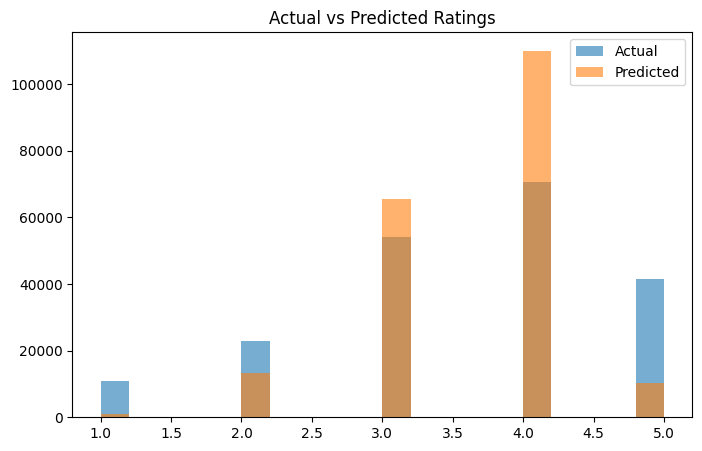

In [ ]:
residual = (y_test - preds)
resi_df =pd.DataFrame({'Actual':y_test, 'Predicted':preds, 'Residual':residual})

plt.figure(figsize=(8,5))
plt.hist(resi_df["Actual"], bins=20, alpha=0.6, label="Actual")
plt.hist(resi_df["Predicted"], bins=20, alpha=0.6, label="Predicted")
plt.title("Actual vs Predicted Ratings")
plt.legend()
plt.show()

**Observation**

*  The model overpredicts rating 4, which is the most common rating.

*  It underpredicts ratings 1, 2, and 5, which are less frequent in the data.

*  Overall, the model captures the general trend but tends to over predictions toward the most common rating (4) due to class imbalance.

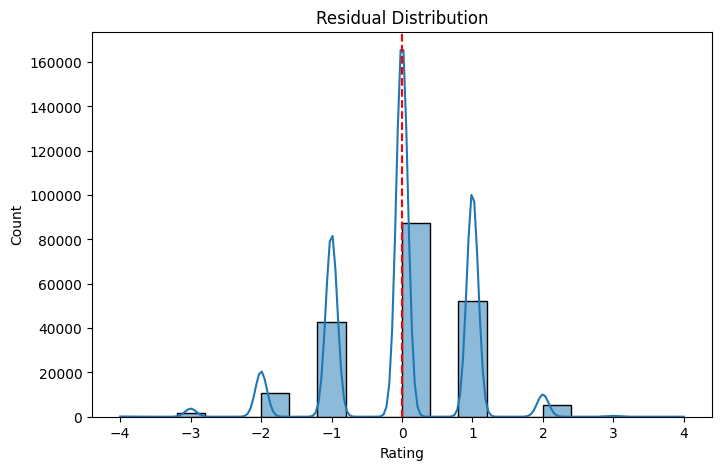

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y_test - preds, bins=20, kde=True)
plt.title("Residual Distribution")
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [ ]:
print("\nSummary Statistics:")
print(resi_df.describe())
print("\nResidual Mean:", resi_df['Residual'].mean())
print("Residual Std", resi_df['Residual'].std())


Summary Statistics:
              Actual      Predicted       Residual
count  200042.000000  200042.000000  200042.000000
mean        3.545790       3.577489      -0.031698
std         1.103388       0.711936       0.940377
min         1.000000       1.000000      -4.000000
25%         3.000000       3.000000      -1.000000
50%         4.000000       4.000000       0.000000
75%         4.000000       4.000000       1.000000
max         5.000000       5.000000       4.000000

Residual Mean: -0.031698343347896944
Residual Std 0.9403769035529315


**Interpretation**

*  Residual distribution is slightly left-tailed.

*  The residual mean is **-0.031**, which indicates that the model is nearly unbiased overall. It is not consistently overpredicting or underpredicting.

**Feature Importance**

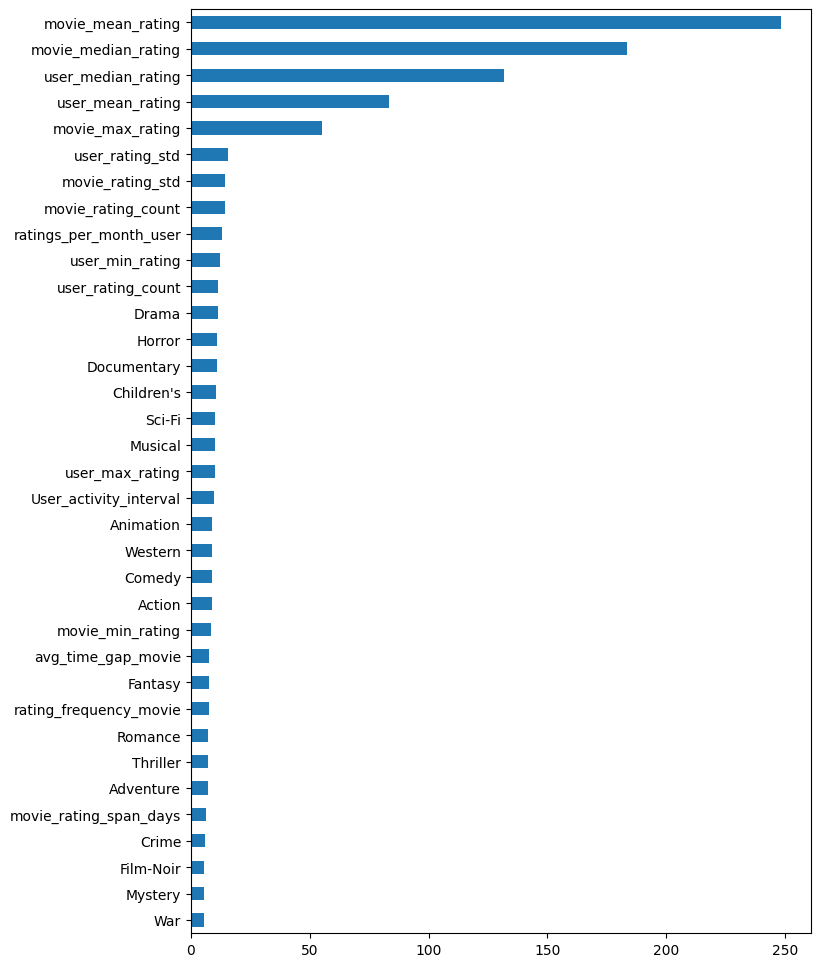

In [ ]:
feature_importances = model.get_booster().get_score(importance_type="gain")
plt.figure(figsize=(8, 12))

fi=pd.Series(
   feature_importances).sort_values(ascending=True).plot(kind='barh')
plt.show()

*  The user's average rating is the most influential feature compared to all others. User and movie related aggregates (average and median ratings) significantly reduce the loss and play a key role in predicting ratings, whereas genre features contribute relatively less.

*   This indicates that the model primarily learns from historical user behavior and movie-level statistics rather than from genre information.

#Matrix Factorization

In [ ]:
mf = ratings.sort_values('Timestamp')
mf=mf.rename(columns={'UserID':'UserId','MovieID':'ItemId'})
split = int(0.8 * len(mf))
train_mf = mf[:split]
test_mf = mf[split:]

In [ ]:
train_mf = train_mf[['UserId', 'ItemId', 'Rating']]
train_mf

,UserId,ItemId,Rating
1000138,6040,858,4
1000153,6040,2384,4
999873,6040,593,5
1000007,6040,1961,4
1000192,6040,2019,5
...,...,...,...
314102,1875,802,4
314151,1875,892,4
314073,1875,440,4
314225,1875,509,4


In [ ]:
test_mf = test_mf[['UserId', 'ItemId', 'Rating']]
test_mf

,UserId,ItemId,Rating
314160,1875,1721,4
314032,1875,2621,4
94555,635,3095,5
94640,635,36,5
94578,635,608,5
...,...,...,...
825793,4958,2399,1
825438,4958,1407,5
825724,4958,3264,4
825731,4958,2634,3


In [ ]:
!pip install cmfrec

In [ ]:
from cmfrec import CMF
model = CMF(method = 'als',
           k=5,
           lambda_ = 0.1,
           user_bias = True,
           item_bias=True,
           verbose =True)
#train
model.fit(train_mf)

#test
users = test_mf['UserId'].values
items = test_mf['ItemId'].values
preds = model.predict(user = users, item = items)

Starting ALS optimization routine

Updating B ... done
Updating A ... done
	Completed ALS iteration  1

Updating B ... done
Updating A ... done
	Completed ALS iteration  2

Updating B ... done
Updating A ... done
	Completed ALS iteration  3

Updating B ... done
Updating A ... done
	Completed ALS iteration  4

Updating B ... done
Updating A ... done
	Completed ALS iteration  5

Updating B ... done
Updating A ... done
	Completed ALS iteration  6

Updating B ... done
Updating A ... done
	Completed ALS iteration  7

Updating B ... done
Updating A ... done
	Completed ALS iteration  8

Updating B ... done
Updating A ... done
	Completed ALS iteration  9

Updating B ... done
Updating A ... done
	Completed ALS iteration 10

ALS procedure terminated successfully


In [ ]:
from sklearn.metrics import  mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
print("CMF Test RMSE:",np.sqrt(mse(test_mf['Rating'], preds)))
print("CMF MAPE:", mape(test_mf['Rating'], preds))

CMF Test RMSE: 0.9968491027720845
CMF MAPE: 0.3012627959251404


**Interpretaion**

*  The model achieved an RMSE of 0.99. This means that, on average, the model's predictions are about 1 rating point away from the true rating.

*  For further improvement, we can tune the model parameters.

In [ ]:
import itertools
k_list = [4,5,8,12]          # latent factors
lambda_list = [0.01, 0.1, 0.3, 0.5]  # regularization

results = []

for k, lambda_ in itertools.product(k_list, lambda_list):
    print(f"Training model with k={k}, lambda_={lambda_} ...")

    model = CMF(
        method='als', k=k, lambda_=lambda_,
        user_bias=True, item_bias=True, verbose=False)

    # Train model
    model.fit(train_mf)

    # Predict on validation set

    y_pred = model.predict(user=users, item=items)

    # Compute RMSE
    rmse = np.sqrt(mse(test_mf['Rating'], y_pred))

    print(f"RMSE: {rmse:.4f}\n")
    results.append({'k': k, 'lambda_': lambda_, 'rmse': rmse})

# =========================
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['rmse'].idxmin()]

print("===== GRID SEARCH RESULTS =====")
print(results_df)
print("\nBest Hyperparameters:")
print(best_row)

Training model with k=4, lambda_=0.01 ...
RMSE: 1.0393

Training model with k=4, lambda_=0.1 ...
RMSE: 0.9805

Training model with k=4, lambda_=0.3 ...
RMSE: 0.9564

Training model with k=4, lambda_=0.5 ...
RMSE: 0.9488

Training model with k=5, lambda_=0.01 ...
RMSE: 1.0531

Training model with k=5, lambda_=0.1 ...
RMSE: 0.9968

Training model with k=5, lambda_=0.3 ...
RMSE: 0.9601

Training model with k=5, lambda_=0.5 ...
RMSE: 0.9525

Training model with k=8, lambda_=0.01 ...
RMSE: 1.0897

Training model with k=8, lambda_=0.1 ...
RMSE: 1.0082

Training model with k=8, lambda_=0.3 ...
RMSE: 0.9741

Training model with k=8, lambda_=0.5 ...
RMSE: 0.9626

Training model with k=12, lambda_=0.01 ...
RMSE: 1.1260

Training model with k=12, lambda_=0.1 ...
RMSE: 1.0400

Training model with k=12, lambda_=0.3 ...
RMSE: 0.9935

Training model with k=12, lambda_=0.5 ...
RMSE: 0.9790

===== GRID SEARCH RESULTS =====
     k  lambda_      rmse
0    4     0.01  1.039343
1    4     0.10  0.980477
2 

**Matrix Fcatorizatio Model 2**

In [ ]:
from cmfrec import CMF
best_model = CMF(method = 'als',
           k=4,
           lambda_ = 0.5,
           user_bias = True,
           item_bias=True,
           verbose =True)
#train
best_model.fit(train_mf)

#test
users = test_mf['UserId'].values
items = test_mf['ItemId'].values
preds = best_model.predict(user = users, item = items)
preds = np.clip(preds, 1, 5)

Starting ALS optimization routine

Updating B ... done
Updating A ... done
	Completed ALS iteration  1

Updating B ... done
Updating A ... done
	Completed ALS iteration  2

Updating B ... done
Updating A ... done
	Completed ALS iteration  3

Updating B ... done
Updating A ... done
	Completed ALS iteration  4

Updating B ... done
Updating A ... done
	Completed ALS iteration  5

Updating B ... done
Updating A ... done
	Completed ALS iteration  6

Updating B ... done
Updating A ... done
	Completed ALS iteration  7

Updating B ... done
Updating A ... done
	Completed ALS iteration  8

Updating B ... done
Updating A ... done
	Completed ALS iteration  9

Updating B ... done
Updating A ... done
	Completed ALS iteration 10

ALS procedure terminated successfully


**Item embeddings**

In [ ]:
best_model.B_

array([[ 0.27678338, -0.09070303, -0.9455878 , -0.3621954 ],
       [-0.01766959,  0.49382943, -0.6629854 ,  0.3404919 ],
       [ 0.31412727, -0.31701297, -0.4854447 , -0.26938343],
       ...,
       [-0.03792487,  0.21209116,  0.46218252,  0.03949391],
       [-0.11836707,  0.21954857, -0.07702328,  0.08695707],
       [ 0.10340266, -0.12967275,  0.13594426,  0.11067102]],
      dtype=float32)

**User embeddings**

In [ ]:
best_model.A_

array([[ 0.33716923,  0.77674127, -0.5298174 , -0.26804104],
       [ 0.22430812,  0.10282689,  0.13122213,  0.26906857],
       [ 0.91257304,  0.31100282,  1.3900307 ,  0.49987307],
       ...,
       [ 0.32429352, -0.00328563, -0.20712075,  0.43304732],
       [-0.6377314 , -0.6455988 ,  0.23402862,  0.4449915 ],
       [ 0.1433761 ,  0.30942643,  0.59055734,  0.14646222]],
      dtype=float32)

In [ ]:
user_ids = list(train_mf['UserId'].unique())
item_ids = list(train_mf['ItemId'].unique())

user_embeddings = pd.DataFrame(best_model.A_, index=user_ids)
item_embeddings = pd.DataFrame(best_model.B_, index=item_ids)

In [ ]:
user_embeddings

,0,1,2,3
6040,0.337169,0.776741,-0.529817,-0.268041
6039,0.224308,0.102827,0.131222,0.269069
6038,0.912573,0.311003,1.390031,0.499873
6037,-0.169130,-0.079842,-0.426315,0.211813
6036,0.034425,0.420772,-0.529779,-0.081022
...,...,...,...,...
639,-0.008119,-0.424498,0.630510,0.766856
638,-0.278525,-0.663475,-0.179132,-0.092343
637,0.324294,-0.003286,-0.207121,0.433047
636,-0.637731,-0.645599,0.234029,0.444991


In [ ]:
item_embeddings

,0,1,2,3
858,0.276783,-0.090703,-0.945588,-0.362195
2384,-0.017670,0.493829,-0.662985,0.340492
593,0.314127,-0.317013,-0.485445,-0.269383
1961,0.438074,-0.089368,-0.097128,0.206530
2019,0.400726,0.350507,-0.579106,-0.166121
...,...,...,...,...
712,0.158375,0.298637,-0.197582,0.191622
3647,-0.093611,-0.000058,-0.033444,-0.006803
634,-0.037925,0.212091,0.462183,0.039494
3458,-0.118367,0.219549,-0.077023,0.086957


In [ ]:
from sklearn.metrics import  mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
print("CMF RSME:", mse(test_mf['Rating'], preds))
print("CMF MAPE:", mape(test_mf['Rating'], preds))

CMF RSME: 0.8972292542457581
CMF MAPE: 0.2910257577896118


**Interpretation**

*  After tuning, the RMSE improved from **0.982 to 0.89**, indicating better generalization and reduced prediction error.

*  However RMSE evaluates rating prediction accuracy, not recommendation quality. To evaluate recommendations, we use K-overlap (Precision@K).

**Matrix Factorization: Recommendation Evaluation using Top-K Overlap**

In [ ]:
k = 10

train_users = set(train_mf["UserId"].unique())
test_users  = set(test_mf["UserId"].unique())
common_users = sorted(train_users & test_users)
rows = []
for user in common_users:
    train_items = set(train_mf[train_mf['UserId'] == user]['ItemId'].values)
    recs = best_model.topN(user = user, n=k)
    recommended = set(recs[:k])

    seen_hits = len(recommended & train_items)
    seen_overlap = seen_hits / k
    rows.append({
        'UserId': user,
        "Overlap_with_Train@k": seen_overlap,
        'Seen_Hits': seen_hits
    })

overlap_train_df = pd.DataFrame(rows)
print(overlap_train_df.head())
print("Average Overlap_with_Train@k:", overlap_train_df["Overlap_with_Train@k"].mean())

   UserId  Overlap_with_Train@k  Seen_Hits
0     635                   0.0          0
1     639                   0.0          0
2     641                   0.0          0
3     646                   0.3          3
4     648                   0.0          0
Average Overlap_with_Train@k: 0.15476815398075242


In [ ]:
k = 10

train_users = set(train_mf["UserId"].unique())
test_users  = set(test_mf["UserId"].unique())

common_users = sorted(test_users & train_users)

rows = []

for user in common_users:
   # Actual interactions in TEST
    actual = set(test_mf[test_mf["UserId"] == user]["ItemId"].values)

    # Recommended top-k items
    recs = best_model.topN(user=user, n=k)      # returns [itemId1, itemId2, ...]
    recommended = set(recs[:k])

    # Overlap
    hits = len(actual & recommended)

    rows.append({
        "UserId": user,
        "precision@k": hits / k,
        "Hits": hits
    })

overlap_df = pd.DataFrame(rows)
print(overlap_df.head())
print("Average precision@k:", overlap_df["precision@k"].mean())

   UserId  precision@k  Hits
0     635          0.0     0
1     639          0.0     0
2     641          0.0     0
3     646          0.3     3
4     648          0.0     0
Average precision@k: 0.04339457567804024


**Interpretation**

*  **Precision@10 : 0.0439** indicates the model is able to capture about 4% of future user interactions. This means out of 10 movies recommended by the system, about 0.4 movies (on average) are actually relevant to the user.
*   Roughly **4 out of 100** recommended movies match what users actually watch or like later.

**Post Model Analysis**

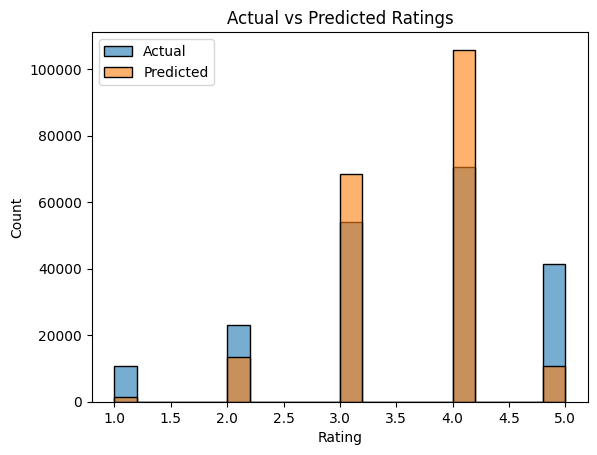

In [ ]:
sns.histplot(test_mf['Rating'], alpha=0.6, bins=20, label='Actual')
preds = np.round(preds).astype(int)
sns.histplot(preds, alpha=0.6, bins=20, label='Predicted')
plt.title("Actual vs Predicted Ratings")
plt.legend()
plt.show()

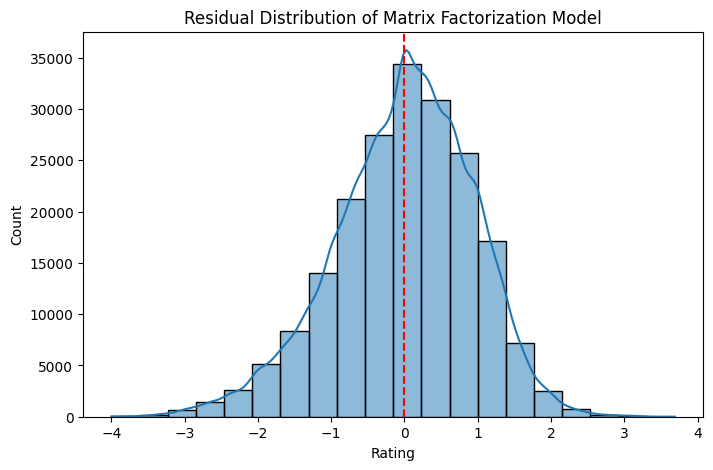

In [ ]:
plt.figure(figsize=(8, 5))
residuals = test_mf['Rating'] - preds
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution of Matrix Factorization Model")
plt.axvline(0, color='red', linestyle='--')
plt.show()

**Interpretation**

*  As observed earlier in the supervised approach, the matrix factorization model also slightly overpredicts for ratings 4 and 5 and underpredicts for ratings1, 2 and 5.

*  The residuals of the matrix factorization model are approximately normally distributed, with a slight left tail indicating minor overprediction. Overall, the model performs well in capturing the latent characteristics of users.

#Item Item Similarities based on embeddings

In [ ]:
train_mf

,UserId,ItemId,Rating
1000138,6040,858,4
1000153,6040,2384,4
999873,6040,593,5
1000007,6040,1961,4
1000192,6040,2019,5
...,...,...,...
314102,1875,802,4
314151,1875,892,4
314073,1875,440,4
314225,1875,509,4


In [ ]:
item_ids = train_mf["ItemId"].unique()

item_id_to_index = {
    item_id: idx
    for idx, item_id in enumerate(item_ids)
}

index_to_item = {
    idx: item_id
    for item_id, idx in item_id_to_index.items()
}

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similar_items_mf(item_id, top_k=5):
    idx = item_id_to_index[item_id]  # get embedding row
    sims = cosine_similarity(
       item_embeddings[idx].reshape(1, -1),
       item_embeddings
    )[0]

    top_idx = sims.argsort()[::-1][1:top_k+1]  # skip itself
    return [(index_to_item[i], sims[i]) for i in top_idx]

In [ ]:
from difflib import get_close_matches
from sklearn.metrics.pairwise import cosine_similarity

unique_movie_ids = movies['MovieID'].unique()
item_ids = train_mf['ItemId'].unique()

# Map MovieID -> ItemId
movieid_to_itemid = {movie_id: idx for idx, movie_id in enumerate(unique_movie_ids)}
itemid_to_movieid = {v: k for k, v in movieid_to_itemid.items()}

# Embedding index mappings
item_id_to_index = {item_id: idx for idx, item_id in enumerate(item_ids)}
index_to_item = {idx: item_id for item_id, idx in item_id_to_index.items()}

# Lowercase title -> ItemId mapping
lower_title_to_itemid = {
    title.lower(): movieid_to_itemid[movie_id]
    for title, movie_id in zip(movies['Title'], movies['MovieID'])
    if movie_id in movieid_to_itemid  # only keep movies with embeddings
}

# similarity function
def similar_items_mf_by_title(user_input, top_k=5, cutoff=0.6):
    user_input_lower = user_input.lower()

    # Step 1
    closest_titles = get_close_matches(user_input_lower, list(lower_title_to_itemid.keys()), n=1, cutoff=cutoff)
    if not closest_titles:
        return f"No close match found for '{user_input}'."

    matched_title_lower = closest_titles[0]
    item_id = lower_title_to_itemid[matched_title_lower]

    # Step 2: Fetch embedding index
    idx = item_id_to_index[item_id]

    # Step 3: Convert to NumPy and compute cosine similarity
    embedding_vector = item_embeddings.iloc[idx].to_numpy() if hasattr(item_embeddings, 'iloc') else item_embeddings[idx]
    embeddings_array = item_embeddings.to_numpy() if hasattr(item_embeddings, 'to_numpy') else item_embeddings
    sims = cosine_similarity(embedding_vector.reshape(1, -1), embeddings_array)[0]

    # Step 4: Top-K similar items (skip itself)
    top_idx = sims.argsort()[::-1][1:top_k+1]

    # Step 5: Map back to movie titles
    results = []
    for i in top_idx:
        movie_id = itemid_to_movieid[index_to_item[i]]
        title = movies.loc[movies['MovieID'] == movie_id, 'Title'].values[0]
        results.append((title, sims[i]))

    # Step 6: Print matched movie first
    original_title = movies.loc[movies['MovieID'] == itemid_to_movieid[item_id], 'Title'].values[0]
    print(f"\nDid you mean: '{original_title}'?\nTop {top_k} similar movies:")

    return results

In [ ]:
user_input = input("Enter a movie name: ")
recommendations = similar_items_mf_by_title(user_input, top_k=5)

for i, (title, score) in enumerate(recommendations, 1):
    print(f"{i}. {title} (similarity: {score:.3f})")

Enter a movie name: liarliar

Did you mean: 'Liar Liar (1997)'?
Top 5 similar movies:
1. Barb Wire (1996) (similarity: 0.984)
2. Species (1995) (similarity: 0.981)
3. Driving Miss Daisy (1989) (similarity: 0.981)
4. Midnight Cowboy (1969) (similarity: 0.979)
5. Agnes Browne (1999) (similarity: 0.971)


#User User Similarities based on user embeddings

In [ ]:
user_emb = best_model.A_
user_emb

array([[ 0.33716947,  0.7767432 , -0.529818  , -0.26804078],
       [ 0.22430597,  0.10282809,  0.13122131,  0.26907033],
       [ 0.9125739 ,  0.3110014 ,  1.3900303 ,  0.49987403],
       ...,
       [ 0.32429257, -0.00328447, -0.20712264,  0.4330488 ],
       [-0.6377316 , -0.64559925,  0.2340273 ,  0.44499308],
       [ 0.1433754 ,  0.30942616,  0.5905555 ,  0.14646347]],
      dtype=float32)

In [ ]:
user_ids = train_mf['UserId'].unique()
user_id_to_index={
    user_id : idx
    for idx, user_id in enumerate(user_ids)

}

index_to_user = {
    idx: user_id
    for user_id, idx in user_id_to_index.items()
}

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similar_users_mf(user_id, top_k=5):
    idx = user_id_to_index[user_id]
    sims = cosine_similarity(
        user_emb[idx].reshape(1, -1),
        user_emb
    )[0]

    top_idx = sims.argsort()[::-1][1:top_k+1]
    return [(index_to_user[i], sims[i]) for i in top_idx]

In [ ]:
list(user_id_to_index.keys())[:10]

[np.int64(6040),
 np.int64(6039),
 np.int64(6038),
 np.int64(6037),
 np.int64(6036),
 np.int64(6035),
 np.int64(6034),
 np.int64(6033),
 np.int64(6032),
 np.int64(6031)]

In [ ]:
similar_users_mf(6031, top_k=5)

[(np.int64(2454), np.float32(0.99981153)),
 (np.int64(4264), np.float32(0.9979789)),
 (np.int64(5182), np.float32(0.9951991)),
 (np.int64(4872), np.float32(0.9941392)),
 (np.int64(2257), np.float32(0.99133396))]

In [ ]:
from cmfrec import CMF
model_2d = CMF(
    method='als',
    k=2,
    lambda_=0.5,
    user_bias=True,
    item_bias=True,
    verbose=False
)
model_2d.fit(train_mf)


Collective matrix factorization model
(explicit-feedback variant)


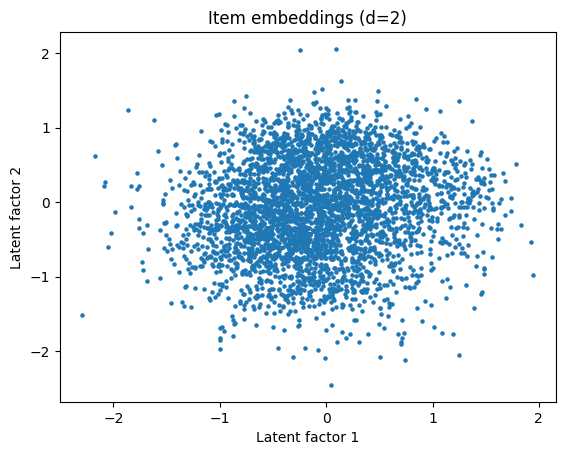

In [ ]:
item_emb_2d = model_2d.B_

plt.scatter(item_emb_2d[:,0], item_emb_2d[:,1], s=5)
plt.title("Item embeddings (d=2)")
plt.xlabel("Latent factor 1")
plt.ylabel("Latent factor 2")
plt.show()

In [ ]:
from cmfrec import CMF
u_model = CMF(
    method='als',
    k=2,
    lambda_=0.5,
    user_bias=True,
    item_bias=True,
    verbose=False
)
u_model.fit(train_mf)

Collective matrix factorization model
(explicit-feedback variant)


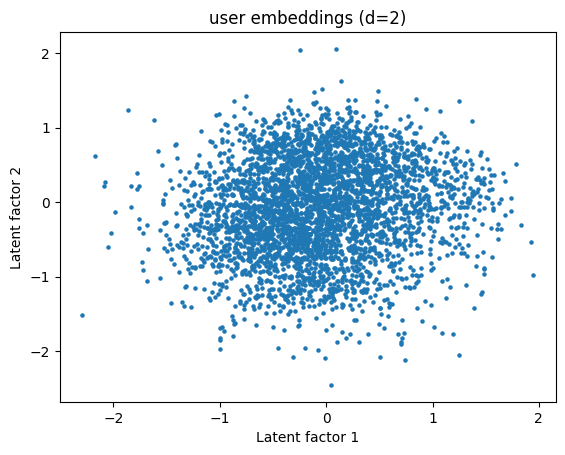

In [ ]:
user_emb_d = u_model.B_

plt.scatter(user_emb_d[:,0], user_emb_d[:,1], s=5)
plt.title("user embeddings (d=2)")
plt.xlabel("Latent factor 1")
plt.ylabel("Latent factor 2")
plt.show()

**Interpretaion**

*  The 2D plot shows that most users are grouped very close to each other. This means most users behave in a similar way, and there are no clear separate groups when we look at only two factors. This suggests that user preferences cannot be explained well using just two dimensions and are more complex.

*  Compared to t-SNE or UMAP, this method keeps the true structure of the model, but it is harder to see clear patterns. Other methods make patterns easier to see, but they change the real distances between users.

#Ask the user to rate a few movies and create a dataframe of the user’s choices.

In [ ]:
#users ratings
new_user_ratings = {
    "Toy Story (1995)": 5,
    "Matrix, The (1999)": 4,
    "Titanic (1997)": 2,
    "Inception (2010)": 5
}

#same movies as the new user.
new_user_df = pd.DataFrame([
    {"UserId": 9999, "Title": k, "Rating": v}
    for k, v in new_user_ratings.items()
])
new_user_df = new_user_df.merge(movies, on="Title")

In [ ]:
new_user_df

,UserId,Title,Rating,MovieID,Genres
0,9999,Toy Story (1995),5,1,Animation|Children's|Comedy
1,9999,"Matrix, The (1999)",4,2571,Action|Sci-Fi|Thriller
2,9999,Titanic (1997),2,1721,Drama|Romance


In [ ]:
#common user
common_users = ratings[
    ratings["MovieID"].isin(new_user_df["MovieID"])
]["UserID"].unique()

In [ ]:
#top 100 users
overlap_counts = (
    ratings[ratings["UserID"].isin(common_users)]
    .groupby("UserID")["MovieID"]
    .nunique()
    .sort_values(ascending=False)
)

top_users = overlap_counts.head(100).index

In [ ]:
# Pearson Correlation
from scipy.stats import pearsonr

def pearson_similarity(user1_df, user2_df):
    merged = pd.merge(
        user1_df, user2_df,
        on="MovieID", suffixes=("_new", "_old")
    )

    if len(merged) < 2:
        return 0

    return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]

In [ ]:
similarities = []

for u in top_users:
    old_user_df = ratings[ratings["UserID"] == u][["MovieID","Rating"]]
    score = pearson_similarity(new_user_df, old_user_df)

    # Avoid NaN
    if np.isnan(score):
        score = 0

    # Optionally ignore negative correlations
    if score > 0:
        similarities.append((u, score))

/tmp/ipython-input-3164480437.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]
/tmp/ipython-input-3164480437.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]
/tmp/ipython-input-3164480437.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]
/tmp/ipython-input-3164480437.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]
/tmp/ipython-input-3164480437.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(merged["Rating_new"], merged["Rating_old"])[0]
/tmp/ipython-input-3

In [ ]:
# Take top 10 users with highest similarity
top_10_users = similarities[:10]

# Convert to DataFrame for easier merge
top_10_df = pd.DataFrame(top_10_users, columns=["UserID", "similarity"])

top_users_ratings = ratings[ratings["UserID"].isin(top_10_df["UserID"])]
top_users_ratings = top_users_ratings.merge(top_10_df, on="UserID")


In [ ]:
top_users_ratings["Weighted Ratings"] = top_users_ratings["Rating"] * top_users_ratings["similarity"]
top_users_ratings.head()

,UserID,MovieID,Rating,Timestamp,similarity,Weighted Ratings
0,1150,3789,4,2000-11-25 23:45:32,0.755929,3.023716
1,1150,1248,3,2000-11-25 23:06:11,0.755929,2.267787
2,1150,2988,3,2000-11-25 23:53:29,0.755929,2.267787
3,1150,1249,4,2000-11-22 05:28:10,0.755929,3.023716
4,1150,571,2,2000-11-22 06:20:26,0.755929,1.511858


In [ ]:
# Aggregate weighted ratings and sum of similarities per movie
recommendations = top_users_ratings.groupby("MovieID").agg(
    total_weighted=("Weighted Ratings", "sum"),
    total_similarity=("similarity", "sum")
)

# Compute predicted rating for each movie
recommendations["predicted_rating"] = (
    recommendations["total_weighted"] / recommendations["total_similarity"]
)

In [ ]:
recommendations = recommendations[
    ~recommendations.index.isin(new_user_df["MovieID"])
]

In [ ]:
top_rated_movies = recommendations[recommendations["predicted_rating"] == 5]

In [ ]:
top_10_recommendations = recommendations.sort_values(
    "predicted_rating", ascending=False
).head(10)

In [ ]:
top_10_recommendations = top_10_recommendations.merge(
    movies, on="MovieID"
)[["Title", "predicted_rating"]]

top_10_recommendations

,Title,predicted_rating
0,Almost Famous (2000),5.0
1,Jean de Florette (1986),5.0
2,"City of Lost Children, The (1995)",5.0
3,"Wings of the Dove, The (1997)",5.0
4,Madeline (1998),5.0
5,FairyTale: A True Story (1997),5.0
6,Anastasia (1997),5.0
7,"Mrs. Brown (Her Majesty, Mrs. Brown) (1997)",5.0
8,Déjà Vu (1997),5.0
9,Angel Baby (1995),5.0


In [ ]:
rat_df = ratings[['MovieID', 'UserID', 'Rating', 'Timestamp']]
meta_df = rat_df.merge(user_agg_features, on='UserID', how='left')
meta_df = meta_df.merge(user_time_based_feats, on='UserID', how='left')
meta_df = meta_df.merge(movie_agg_feats, on='MovieID', how='left')
meta_df = meta_df.merge(movie_time_based_feats, on='MovieID', how='left')
meta_df = meta_df.merge(df, on='MovieID', how='left')
meta_df = meta_df.merge(users, on='UserID', how='left')


TypeError: Can only merge Series or DataFrame objects, a <class 'numpy.ndarray'> was passed

In [ ]:
df

Genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
MovieID,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3949,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3950,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
mat_fac = mf[['UserId', 'ItemId', 'Rating']]
mat_fac.columns

Index(['UserId', 'ItemId', 'Rating'], dtype='object')

In [ ]:
meta_df.columns

Index(['MovieID', 'UserID', 'Rating', 'user_mean_rating', 'user_median_rating',
       'user_rating_std', 'user_rating_count', 'user_min_rating',
       'user_max_rating', 'User_activity_interval', 'ratings_per_month_user',
       'movie_mean_rating', 'movie_median_rating', 'movie_rating_std',
       'movie_rating_count', 'movie_min_rating', 'movie_max_rating',
       'movie_rating_span_days', 'avg_time_gap_movie',
       'rating_frequency_movie', 'Action', 'Adventure', 'Animation',
       'Children's', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
       'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
       'Thriller', 'War', 'Western', 'Gender', 'Age', 'Occupation',
       'Zip-code'],
      dtype='object')

In [ ]:
#Extract latent embeddings
user_factors = best_model.B_   # shape: (n_users, k)
item_factors = best_model.A_

print(user_factors.shape)
print(item_factors.shape)

(3662, 4)
(5400, 4)


In [ ]:
mf_users = set(best_model.user_mapping_)
mf_items = set(best_model.item_mapping_)

hybrid_train = mat_fac[
    mat_fac['UserId'].isin(mf_users) &
    mat_fac['ItemId'].isin(mf_items)
]

In [ ]:
user_id_to_index = {u:i for i,u in enumerate(best_model.user_mapping_)}
item_id_to_index = {i:j for j,i in enumerate(best_model.item_mapping_)}
k = best_model.k

In [ ]:
user_id_to_index = {
    u:i for i,u in enumerate(best_model.user_mapping_)
    if i < best_model.B_.shape[0]
}

item_id_to_index = {
    i:j for j,i in enumerate(best_model.item_mapping_)
    if j < best_model.A_.shape[0]
}

In [ ]:
hybrid_train = mat_fac[
    mat_fac['UserId'].isin(user_id_to_index.keys()) &
    mat_fac['ItemId'].isin(item_id_to_index.keys())
]

In [ ]:
hybrid_train['u_vec'] = hybrid_train['UserId'].map(
    lambda u: best_model.B_[ user_id_to_index[u] ]
)

hybrid_train['i_vec'] = hybrid_train['ItemId'].map(
    lambda i: best_model.A_[ item_id_to_index[i] ]
)

/tmp/ipython-input-2552825293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hybrid_train['u_vec'] = hybrid_train['UserId'].map(
/tmp/ipython-input-2552825293.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hybrid_train['i_vec'] = hybrid_train['ItemId'].map(


In [ ]:
hybrid_train = hybrid_train.merge(
    meta_df,
    left_on=['UserId','ItemId'],
    right_on=['UserID','MovieID'],
    how='left'
)

In [ ]:
meta_cols = [
    'user_mean_rating','user_median_rating','user_rating_std',
    'user_rating_count','user_min_rating','user_max_rating',
    'User_activity_interval','ratings_per_month_user',
    'movie_mean_rating','movie_median_rating','movie_rating_std',
    'movie_rating_count','movie_min_rating','movie_max_rating',
    'movie_rating_span_days','avg_time_gap_movie',
    'rating_frequency_movie',

    # Genres
    'Action','Adventure','Animation',"Children's",'Comedy','Crime',
    'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
    'Mystery','Romance','Sci-Fi','Thriller','War','Western',

    # Demographics
    'Gender','Age','Occupation'
]

In [ ]:
hybrid_train = hybrid_train.rename(columns={'Rating_x': 'Rating'})

In [ ]:
import numpy as np

X_mf = np.hstack([
    np.vstack(hybrid_train['u_vec']),
    np.vstack(hybrid_train['i_vec'])
])

X_meta = hybrid_train[meta_cols].values

X = np.hstack([X_mf, X_meta])
y = hybrid_train['Rating'].values

In [ ]:
print(hybrid_train.columns)

Index(['UserId', 'ItemId', 'Rating_x', 'u_vec', 'i_vec', 'MovieID', 'UserID',
       'Rating_y', 'user_mean_rating', 'user_median_rating', 'user_rating_std',
       'user_rating_count', 'user_min_rating', 'user_max_rating',
       'User_activity_interval', 'ratings_per_month_user', 'movie_mean_rating',
       'movie_median_rating', 'movie_rating_std', 'movie_rating_count',
       'movie_min_rating', 'movie_max_rating', 'movie_rating_span_days',
       'avg_time_gap_movie', 'rating_frequency_movie', 'Action', 'Adventure',
       'Animation', 'Children's', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance',
       'Sci-Fi', 'Thriller', 'War', 'Western', 'Gender', 'Age', 'Occupation',
       'Zip-code'],
      dtype='object')


In [ ]:
hybrid_train = hybrid_train.sort_values('Timestamp')

split_idx = int(0.8 * len(hybrid_train))

train_df = hybrid_train.iloc[:split_idx]
test_df  = hybrid_train.iloc[split_idx:]

KeyError: 'Timestamp'

**1. Pearson Correlation (User-User / Item-Item CF)**

**Metrics:**

   *  RMSE = 1.201

   *  MAE = 0.949

**Interpretation:**

The Pearson-based collaborative filtering model shows the weakest performance among all approaches. An RMSE of 1.201 on a 1-5 rating scale indicates relatively high prediction error, meaning the model often deviates by about one full rating point from the true value.

**Reasons:**

  *  Highly sensitive to data sparsity.

  *  Struggles when users have few overlapping ratings.

  *  Performs poorly for cold-start users/items.

**Business implication:**

Not suitable as a standalone model in real-world systems, but useful as a baseline.

**2. Cosine Similarity + kNN**

**Metrics:**

  *  Precision ≈ 15.4%

  *  HitRate@10 = 0.0

**Interpretation:**

The cosine model performs better than Pearson in terms of top-N relevance, with around 15% of recommended items being relevant. However, the HitRate@10 of 0 suggests the model failed to recommend any item that users actually interacted with in the test set.

**Reasons:**

  *  Works well for dense users.

  *  Still suffers from cold-start and popularity bias.

  *  HitRate failure indicates poor ranking quality.

**Business implication:**

Moderate performance for exploratory recommendations, but unreliable for personalized ranking.

**3. Matrix Factorization (Collaborative MF)**

**Metrics:**

  * RMSE = 0.897

  * MAPE = 0.291 (29.1%)

**Precision@10 = 4.39%**

**Interpretation:**

Matrix Factorization achieves the lowest RMSE, meaning it predicts ratings most accurately overall. However, the Precision@10 is low, indicating that while rating predictions are good, the top-10 recommendation list is weak.

MF optimizes error minimization, not ranking quality.

**Business implication:**

Excellent for rating prediction, less effective for real-time recommendation lists.

**4. Supervised XGBoost (Cold Start Model)**

**Metrics:**

  *  RMSE = 0.941

**Interpretation:**

The supervised model performs almost as well as Matrix Factorization and significantly better than Pearson. Since it uses content features, it handles cold-start users/items effectively.

**Strengths:**

  * Works without historical interactions.

  * Captures non-linear patterns.

  * More stable across sparse scenarios.

**Business implication:**

Ideal as a cold-start engine and can be integrated into a hybrid system.

Overall, Pearson, Cosine, and Matrix Factorization serve different purposes, with each model being effective under different user and data conditions.

#Recommendations for Improvement

*  Building a hybrid system by combining XGBoost (cold-start), Matrix Factorization (warm users), and Cosine Similarity (similar-item discovery) can improve accuracy.

*  Instead of using RMSE alone, optimizing metrics such as NDCG@K, MAP@K, and Hit Rate will better reflect user satisfaction.

*  Adding more signals (features) like popularity trends and recency can enhance recommendations.

*  The Zee platform should track models using Click-through Rate (CTR), Watch Time, and Conversion Rate to improve model performance.

*  Deploying the recommender system in real-time and running A/B tests will help understand user engagement and business impact.

*  Using deep learning and real-time personalization can further improve the system's performance and scalability.

#Questionnaire

**1. Users of which age group have watched and rated the most number of movies?**

Users in the **25-34 age group** have watched and rated the highest number of movies.

**2. Users belonging to which profession have watched and rated the most movies?**

Users belonging to the **College/Grad Student** occupation have watched and rated the most movies, followed by **Not Specified** and the **Managerial category**.

**3. Most of the users in our dataset who've rated the movies are Male. (T/F)**

**True.** Users in this dataset who've rated the movies are Male

**4. Most of the movies present in our dataset were released in which decade?
70s b. 90s c. 50s d.80s**

Most of the movies prrsent in this dataset were released in the **90's decade.**

**5. The movie with maximum no. of ratings is American Beauty (1999).**

**6. Name the top 3 movies similar to Liar Liar on the item-based approach.**

Top 3 movies similar to liar liar are:

1. Mrs. Doubtfire (1993) (score: 0.624)
2. Ace Ventura: Pet Detective (1994) (score: 0.609)
3. There's Something About Mary (1998) (score: 0.6)

**7. On the basis of approach, Collaborative Filtering methods can be classified into user-based and item-based.**

**8. Pearson Correlation ranges between ___ to ___ whereas, Cosine Similarity belongs to the interval between ___ to ___.**

*  Pearson Correlation ranges between -1 to 1

*  Cosine Similarity belongs to the interval between 0 to 1.

**9. Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.**

*  MF RSME: 0.8972292542457581

*  MF MAPE: 0.2918972671031952

**10. Give the sparse row matrix representation for the following dense matrix -
[[1 0]
[3 7]]**

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix

dense = np.array([[1, 0],
                  [3, 7]])

sparse = csr_matrix(dense)

print(sparse)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (2, 2)>
  Coords	Values
  (0, 0)	1
  (1, 0)	3
  (1, 1)	7
